# Synthèse des scores des estimateurs

# Sommaire

- Importation des librairies

- Approche Supervisée
	- Importation des modèles
	- Synthèse des résultats des entraînements en supervisé
	- Détail sur les itérations des entrainements 
	- Etude du meilleur estimateur supervisé
	- Analyse de la répartition des tags

- Approche Non Supervisée
	- Etude de l'approche LDA

- Comparaison Supervisé vs LDA



# Importation des librairies

In [1]:
# Importation générale
import pandas as pd
# pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import joblib

C:\Users\daims\anaconda3\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
C:\Users\daims\anaconda3\lib\site-packages\numpy\.libs\libopenblas.EL2C6PLE4ZYW3ECEVIV3OXXGRN2NRFM2.gfortran-win_amd64.dll
C:\Users\daims\anaconda3\lib\site-packages\numpy\.libs\libopenblas.PYQHXLVVQ7VESDPUVUADXEVJOBGHJPAY.gfortran-win_amd64.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


In [2]:
# Importation des librairies pour la prédiction

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer

from sklearn.pipeline import Pipeline
from sklearn import linear_model
from sklearn.kernel_ridge import KernelRidge
from sklearn.svm import SVR
from sklearn import tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor


# Visualisation des diagrammes
from sklearn import set_config


In [3]:
# # Permet d'élargir le notebook
# from IPython.core.display import display, HTML
# display(HTML("<style>.container { width:70% !important; }</style>"))

In [4]:
# os.getcwd()

# Importation des modèles

In [5]:
## Import des modèles entrainés et de leur R2 score sur le dataset d'entraînement
import os

## Import des modèles entrainés

path_folder = 'D:\\Utilisateurs\\Damien\\Documents\\Test_code\\test_python\\OCR_projets\\IML\\P5_'

sub_path_1 = '\\test_v1_100tags' # train on different parameters grids and some text preprocessing errors
sub_path_2 = '\\test_v2_100tags'
sub_path_3 = '\\test_v2_lda'

path_gen = path_folder + sub_path_2
path_gen_lda = path_folder + sub_path_3

# Récupération des noms de fichier au sein du dossier contenant les modèles entrainés et enregistrés
directories = os.listdir( path_gen )
directories_lda = os.listdir( path_gen_lda )
directories


['cvect_input_pipe_pac_cv.pkl',
 'cvect_input_pipe_rc_cv.pkl',
 'cvect_input_pipe_rf_cv.pkl',
 'features_768_bert_pac_cv.pkl',
 'features_768_bert_rc_cv.pkl',
 'features_768_bert_rf_cv.pkl',
 'features_768_lanwuwei_bert_pac_cv.pkl',
 'features_768_lanwuwei_bert_rc_cv.pkl',
 'features_768_lanwuwei_bert_rf_cv.pkl',
 'tfidf_input_pipe_pac_cv.pkl',
 'tfidf_input_pipe_rc_cv.pkl',
 'tfidf_input_pipe_rf_cv.pkl',
 'use_pac_cv_512_.pkl',
 'use_rc_cv_512_.pkl',
 'use_rf_cv_512_.pkl',
 'w2v_pac_cvfeatures_300.pkl',
 'w2v_rc_cvfeatures_300.pkl',
 'w2v_rf_cv_features_300.pkl']

Dans cette liste de fichiers, les annotations repreésentent:

- cvect_input: Entrée avec préprocessing de type Count Vectorizer  


- tfidf_input: Entrée avec préprocessing de type TF-IDF  


- w2v: Entrée avec préprocessing de type Words to Vectors
    - w2v_pac_cvfeatures_300: W2V dont la matrice d'embedding possède 300 features et entraînée ensuite par un modèle de type pac.
- use: Entrée avec préprocessing de type USE: Universal Sentence Encoder
    - use_rf_cv_512_: USE dont la matrice d'embedding possède 512 features et entraînée ensuite par un modèle de type RF.
- bert: Entrée avec préprocessing de type BERT
    - features_768_lanwuwei_bert_pac_cv: BERT préentrainé sur le vocabulaire de "lanwuwei" dont la matrice d'embedding possède 768 features et entraînée ensuite par un modèle de type pac.  


- pipe: Relatif à une pipeline avec un estimateur
- cv: Relatif à Cross Validation  


- rc: Ridge Classifier
- rf:  Random Forest
- pac: Passive Agressive Classifier  


#### Définition da la fonction de score pour les estimateurs supervisés

In [6]:
from sklearn.metrics import jaccard_score, make_scorer

# -------------- Define scoring functions
def jaccard_func(y_true, y_pred):
    result_score = jaccard_score(y_true, y_pred, average='samples',zero_division=0)
    return result_score

# -------------- Score and error functions
score_jaccard_func = make_scorer(jaccard_func, greater_is_better=True)
scoring_model = {'score_jaccard_func':score_jaccard_func, 'accuracy':'accuracy'}


On charge les modèles récursivement dans une liste appelée estimator_list:

In [7]:
# This would print all the files and directories
estimator_list = []
for file in directories:
    print(file)
    estimator = joblib.load(path_gen + "/" + file)
    estimator_list.append(estimator)

cvect_input_pipe_pac_cv.pkl
cvect_input_pipe_rc_cv.pkl
cvect_input_pipe_rf_cv.pkl
features_768_bert_pac_cv.pkl
features_768_bert_rc_cv.pkl
features_768_bert_rf_cv.pkl
features_768_lanwuwei_bert_pac_cv.pkl
features_768_lanwuwei_bert_rc_cv.pkl
features_768_lanwuwei_bert_rf_cv.pkl
tfidf_input_pipe_pac_cv.pkl
tfidf_input_pipe_rc_cv.pkl
tfidf_input_pipe_rf_cv.pkl
use_pac_cv_512_.pkl
use_rc_cv_512_.pkl
use_rf_cv_512_.pkl
w2v_pac_cvfeatures_300.pkl
w2v_rc_cvfeatures_300.pkl
w2v_rf_cv_features_300.pkl


Définition de fonctions de visualisation graphiques des scores moyen de validation croisée suite à la recherche d'hyperparamètre dans la grille de valeru choisie.

In [8]:
def plot_results(estimator,estimator_name):
    plt.figure(figsize=(18,14))
    #plt.suptitle(str(f'{estimator=}'.split('=')[0]))
    plt.suptitle(estimator_name, fontsize=20)
    ax = plt.gca()

    plt.subplot(3,1,1)
    plt.plot(list(range(len(estimator.cv_results_['mean_train_score'].data))), estimator.cv_results_['mean_train_score'])
    plt.plot(list(range(len(estimator.cv_results_['mean_test_score'].data))), estimator.cv_results_['mean_test_score'])
    plt.legend(['mean_train_score','mean_test_score'])
    plt.grid()
    plt.xlabel('Iteration')
    plt.ylabel('Scores')
    
    plt.subplot(3,1,2)
    plt.plot(list(range(len(estimator.cv_results_['std_train_score'].data))), estimator.cv_results_['std_train_score'])
    plt.plot(list(range(len(estimator.cv_results_['std_test_score'].data))), estimator.cv_results_['std_test_score'])
    plt.legend(['std_train_score','std_test_score'])
    plt.grid()
    plt.xlabel('Iteration')
    plt.ylabel('Scores')

    plt.subplot(3,1,3)
    plt.plot(list(range(len(estimator.cv_results_['mean_train_score'].data))), estimator.cv_results_['mean_fit_time'])
    plt.legend(['mean_fit_time'])
    plt.grid()
    plt.xlabel('Iteration')
    plt.ylabel('Scores')
    
    # plt.axis('tight')
    plt.show()


In [9]:
def plot_results2(estimator,estimator_name,score_name):
    plt.figure(figsize=(18,14))
    #plt.suptitle(str(f'{estimator=}'.split('=')[0]))
    plt.suptitle(estimator_name, fontsize=20)
    ax = plt.gca()
    
    mean_train = 'mean_train_' + score_name
    mean_test = 'mean_test_' + score_name
    std_train = 'std_train_' + score_name
    std_test =  'std_test_' + score_name
    
    plt.subplot(3,1,1)
    plt.plot(list(range(len(estimator.cv_results_[mean_train].data))), estimator.cv_results_[mean_train])
    plt.plot(list(range(len(estimator.cv_results_[mean_test].data))), estimator.cv_results_[mean_test])
    plt.legend([mean_train,mean_test])
    plt.grid()
    plt.xlabel('Iteration')
    plt.ylabel('Scores')
    
    plt.subplot(3,1,2)
    plt.plot(list(range(len(estimator.cv_results_[std_train].data))), estimator.cv_results_[std_train])
    plt.plot(list(range(len(estimator.cv_results_[std_test].data))), estimator.cv_results_[std_test])
    plt.legend([std_train,std_test])
    plt.grid()
    plt.xlabel('Iteration')
    plt.ylabel('Scores')

    plt.subplot(3,1,3)
    plt.plot(list(range(len(estimator.cv_results_['mean_fit_time'].data))), estimator.cv_results_['mean_fit_time'])
    plt.legend(['mean_fit_time'])
    plt.grid()
    plt.xlabel('Iteration')
    plt.ylabel('Scores')
    
    # plt.axis('tight')
    plt.show()


# Synthèse des résultats des entraînements en supervisé  

#### Lecture des meilleurs paramètres

In [10]:
# Lecture des meilleurs paramètres par estimateur
for i in range(0,len(estimator_list)):
    print(directories[i] + ' best parameters are: ' + str(estimator_list[i].best_params_) + '\n')

cvect_input_pipe_pac_cv.pkl best parameters are: {'cvect_input__max_df': 0.3, 'cvect_input__min_df': 1, 'model_pac__estimator__C': 1.0}

cvect_input_pipe_rc_cv.pkl best parameters are: {'cvect_input__max_df': 0.5, 'cvect_input__min_df': 1, 'model_rc__estimator__alpha': 5.0}

cvect_input_pipe_rf_cv.pkl best parameters are: {'cvect_input__max_df': 0.3, 'cvect_input__min_df': 10}

features_768_bert_pac_cv.pkl best parameters are: {'estimator__C': 0.1}

features_768_bert_rc_cv.pkl best parameters are: {'estimator__alpha': 0.5}

features_768_bert_rf_cv.pkl best parameters are: {'estimator__min_samples_leaf': 1}

features_768_lanwuwei_bert_pac_cv.pkl best parameters are: {'estimator__C': 0.7}

features_768_lanwuwei_bert_rc_cv.pkl best parameters are: {'estimator__alpha': 0.5}

features_768_lanwuwei_bert_rf_cv.pkl best parameters are: {'estimator__min_samples_leaf': 1}

tfidf_input_pipe_pac_cv.pkl best parameters are: {'model_pac__estimator__C': 0.1, 'tfidf_input__max_df': 0.9, 'tfidf_input__

In [11]:
# Lecture des meilleurs scores par estimateur
# for i in range(0,len(estimator_list)):
#     print(directories[i] +' score is: ' + str(estimator_list[i].best_score_))

On rassemble les scores dans des listes dont on fera une visualisation graphique:

In [12]:
score_list = []
mean_fit_time_list = []
for i in range(0,len(estimator_list)):
#     print(str(i))
    score_list.append(estimator_list[i].best_score_)
    mean_fit_time_list.append(estimator_list[i].cv_results_['mean_fit_time'].mean())
    

In [13]:
tab_score_gscv = pd.DataFrame({'mean_test_score':score_list,'mean_fit_time':mean_fit_time_list
                         },
            index = directories)

In [14]:
# Mean cross-validated score of the best_estimator
tab_score_gscv

,mean_test_score,mean_fit_time
cvect_input_pipe_pac_cv.pkl,0.424564,3.791258
cvect_input_pipe_rc_cv.pkl,0.321330,117.837586
cvect_input_pipe_rf_cv.pkl,0.307693,213.607401
features_768_bert_pac_cv.pkl,0.308648,50.029944
features_768_bert_rc_cv.pkl,0.185049,9.675216
features_768_bert_rf_cv.pkl,0.030336,2446.626514
features_768_lanwuwei_bert_pac_cv.pkl,0.243074,41.470923
features_768_lanwuwei_bert_rc_cv.pkl,0.168880,9.815490
features_768_lanwuwei_bert_rf_cv.pkl,0.008383,2760.638265
tfidf_input_pipe_pac_cv.pkl,0.481181,4.438312


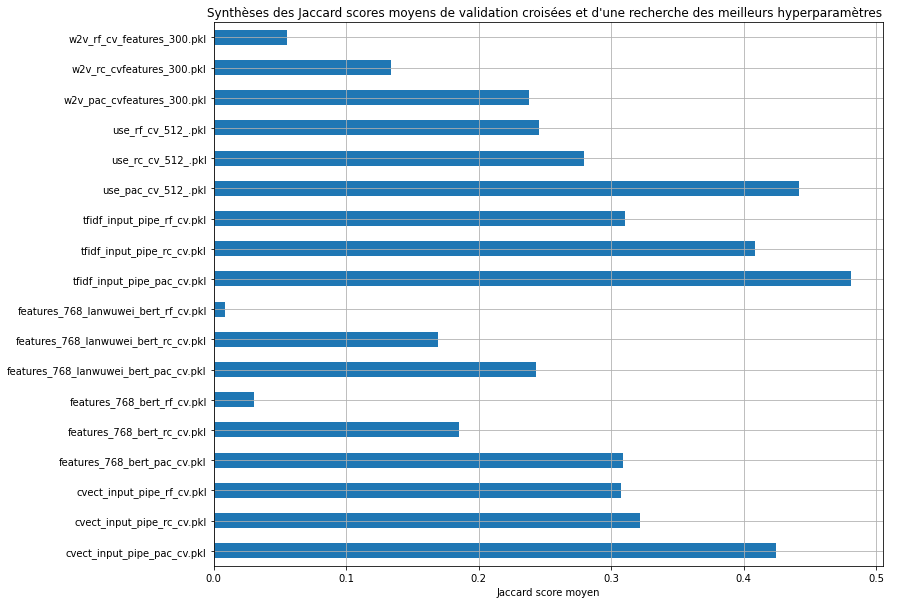

In [15]:
# Horizontal barplot of mean_test_score
plt.figure(figsize=(12,10))
tab_score_gscv['mean_test_score'].plot.barh()
plt.title("Synthèses des Jaccard scores moyens de validation croisées et d'une recherche des meilleurs hyperparamètres  ")
plt.xlabel("Jaccard score moyen")
plt.grid()
plt.show()

Ici, le meilleur estimateur est "tfidf_input_pipe_pac_cv" avec un score moyen de 0.48. Son temps d'apprentissage fait d'ailleurs parti des plus rapides. On va donc l'utiliser par la suite pour prédire nos tags.  
La technique USE semble donner des résultats assez intéressant aussi.  
Les méthodes utilisant l'approche BERT dépendent essentiellement de la base de textes de vocabulaire utiliséee lors du pré-entrainement. Une utilisation avec un vocabulaire plus spécifique pourrait être intéressant.  

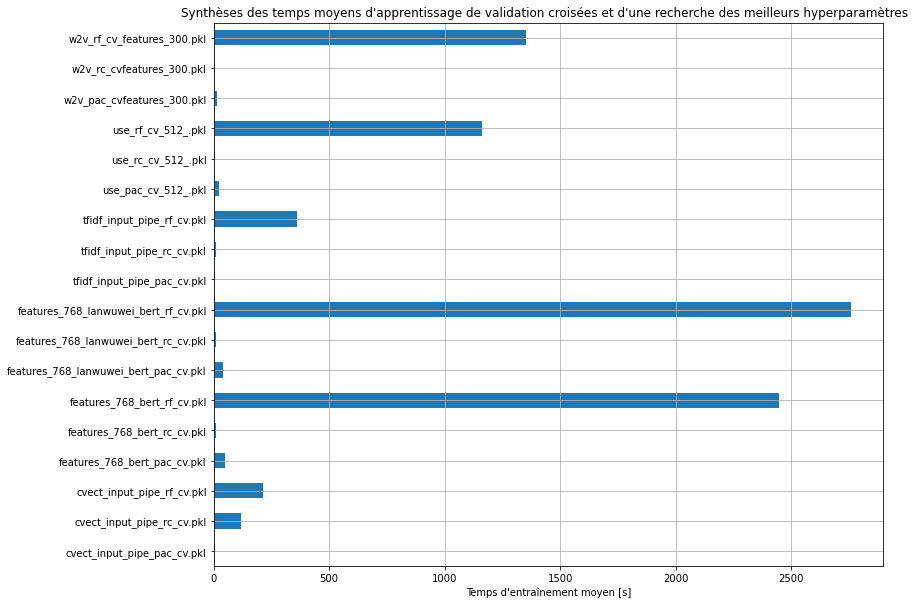

In [16]:
# Horizontal barplot of mean_fit_time
plt.figure(figsize=(12,10))
tab_score_gscv['mean_fit_time'].plot.barh()
plt.title("Synthèses des temps moyens d'apprentissage de validation croisées et d'une recherche des meilleurs hyperparamètres  ")
plt.xlabel("Temps d'entraînement moyen [s]")
plt.grid()
plt.show()

On conscaste ici que les approche à base de forêts aléatoires sont très gourmandes en temps de calcul, et notamment plus importantes dans le cas BERT et W2V. Les approches bags of words classiques avec countvectorizer sont un petit plus gourmande que les autres. 

On constate par ailleurs que les estimateurs utilisant le modèle PAC sont généralement plus rapides que les autres types de modèles avec des scores souvent très intéressant parmis les modèles testés.


# Détail sur les itérations des entraînements

Le détails des scores des différentes validations croisées est représenté par des graphes d'incrément:

{'cvect_input__max_df': 0.3, 'cvect_input__min_df': 1, 'model_pac__estimator__C': 1.0}
0.42456395461078084


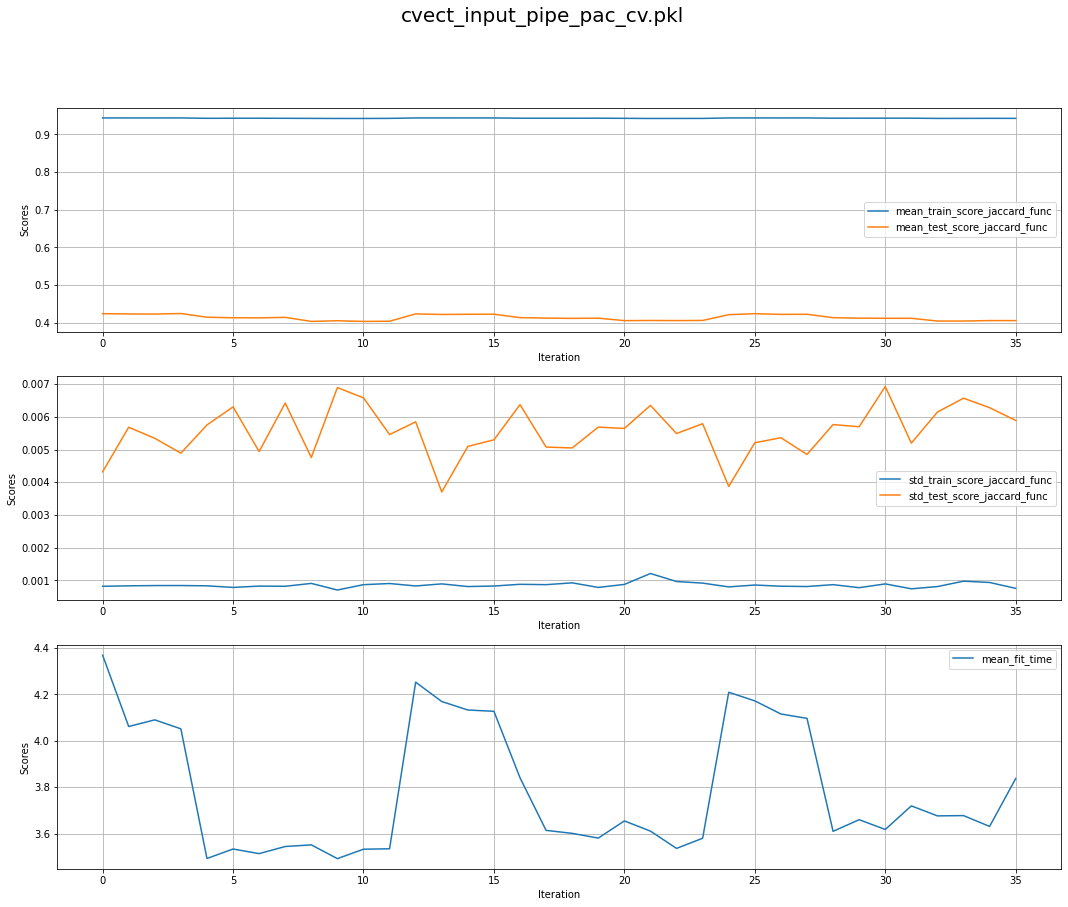

{'cvect_input__max_df': 0.5, 'cvect_input__min_df': 1, 'model_rc__estimator__alpha': 5.0}
0.3213304694635504


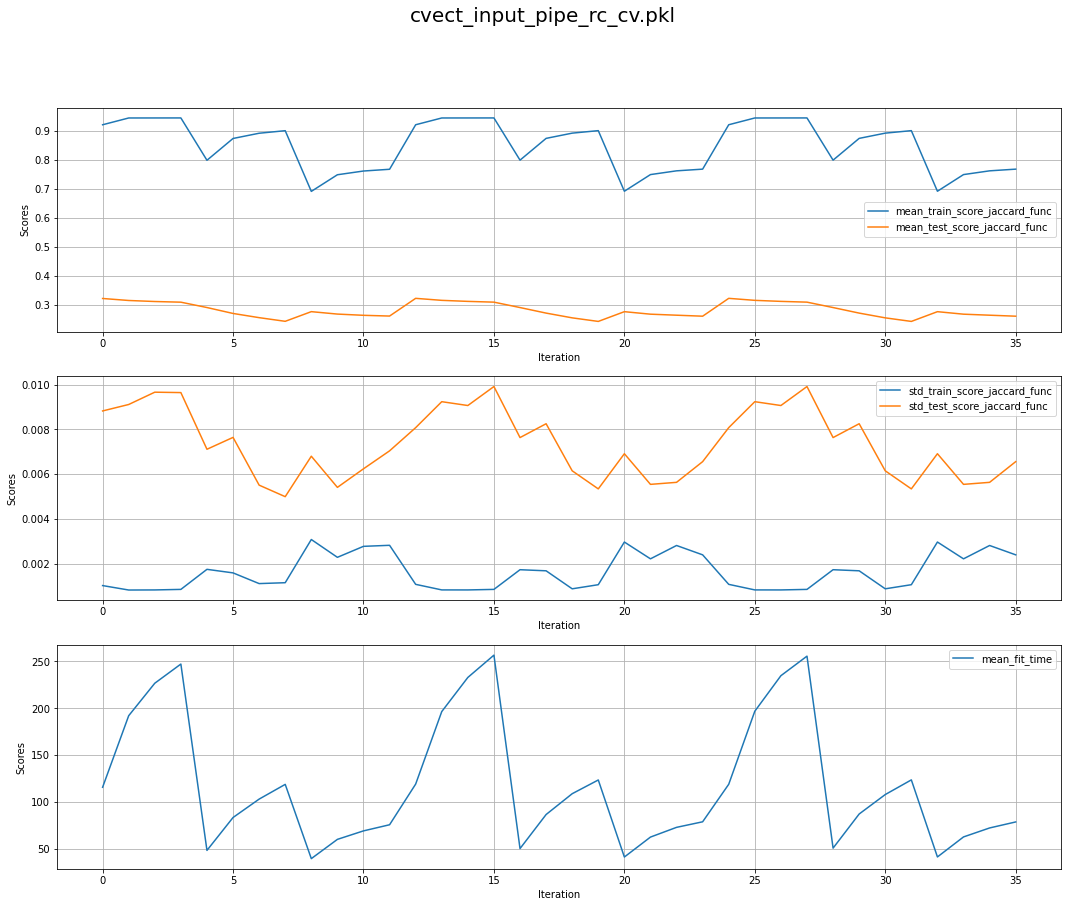

{'cvect_input__max_df': 0.3, 'cvect_input__min_df': 10}
0.3076932467232184


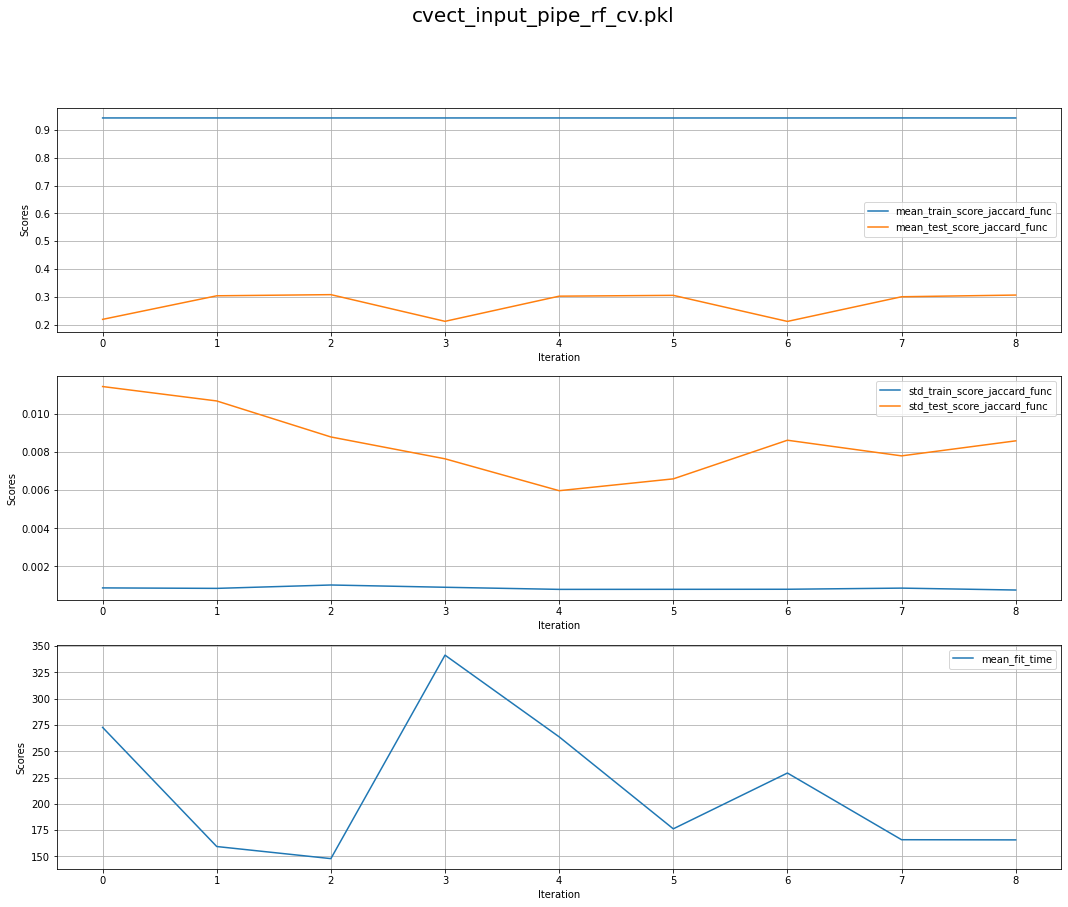

{'estimator__C': 0.1}
0.30864770420348775


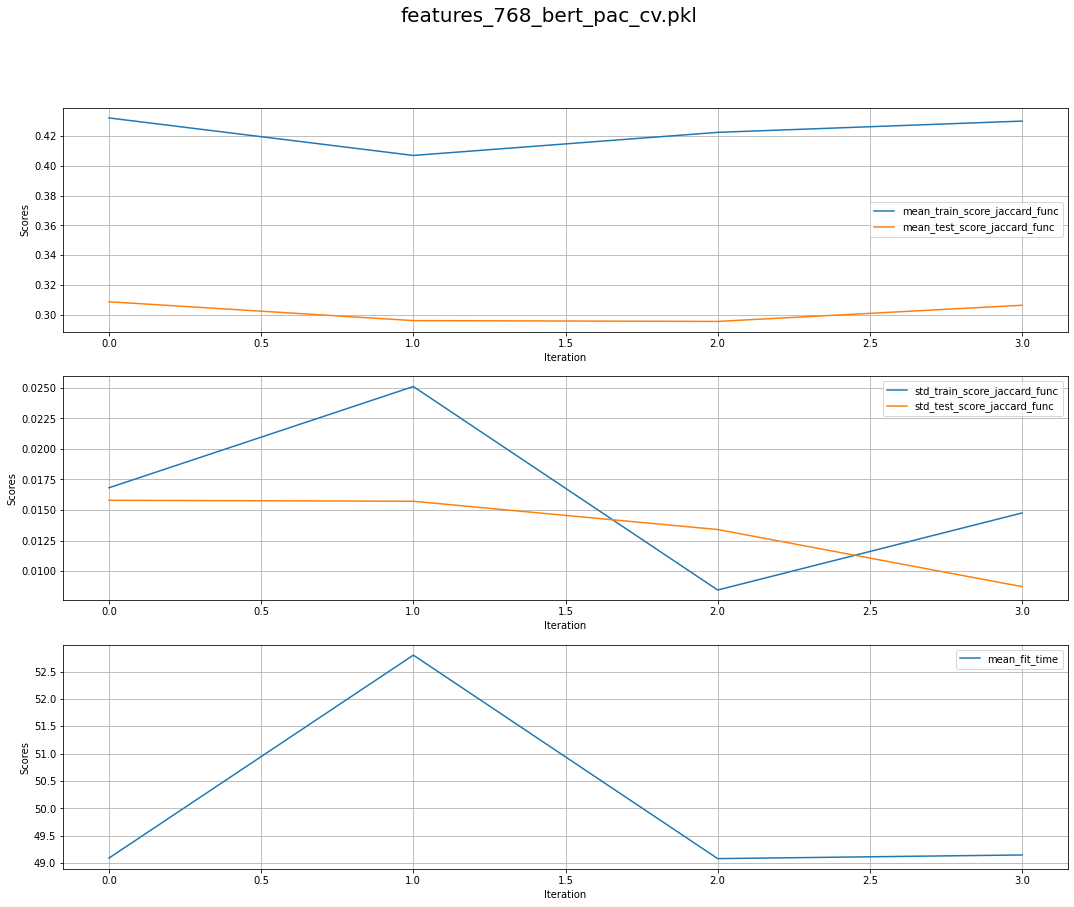

{'estimator__alpha': 0.5}
0.1850486462930142


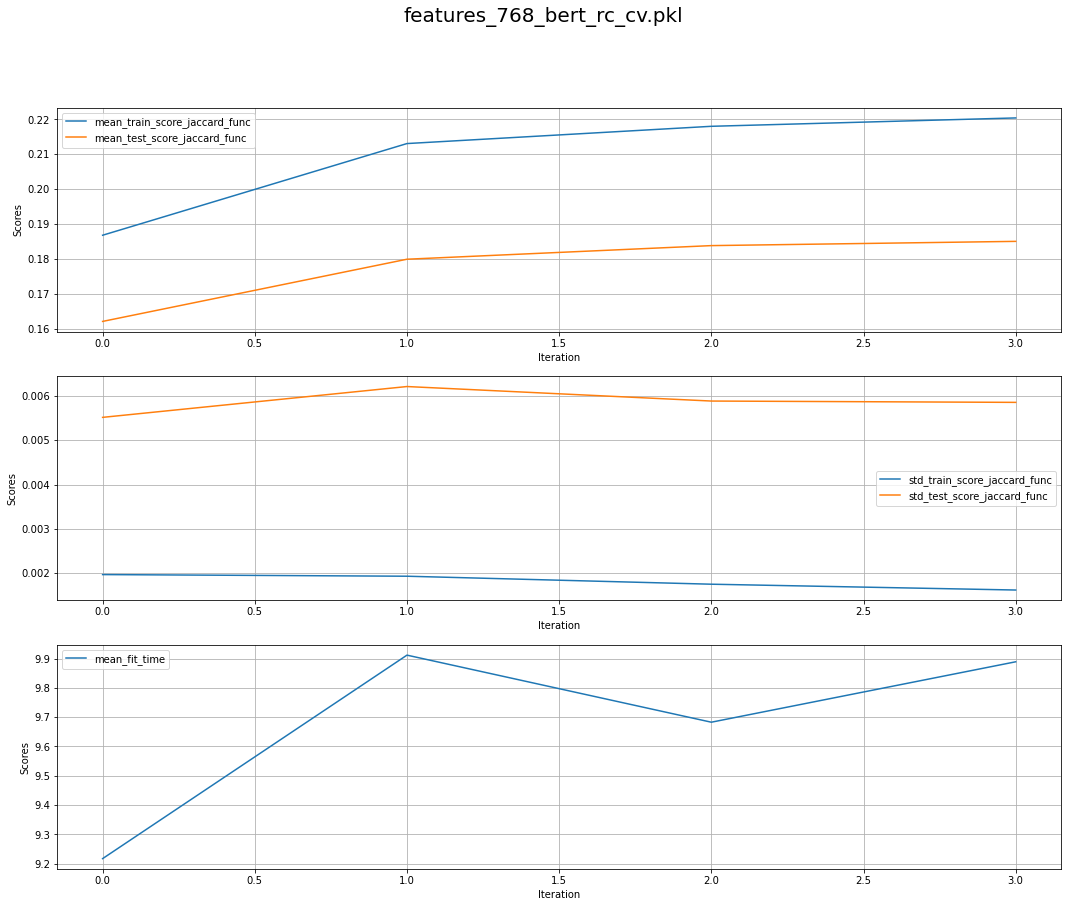

{'estimator__min_samples_leaf': 1}
0.030336080418635298


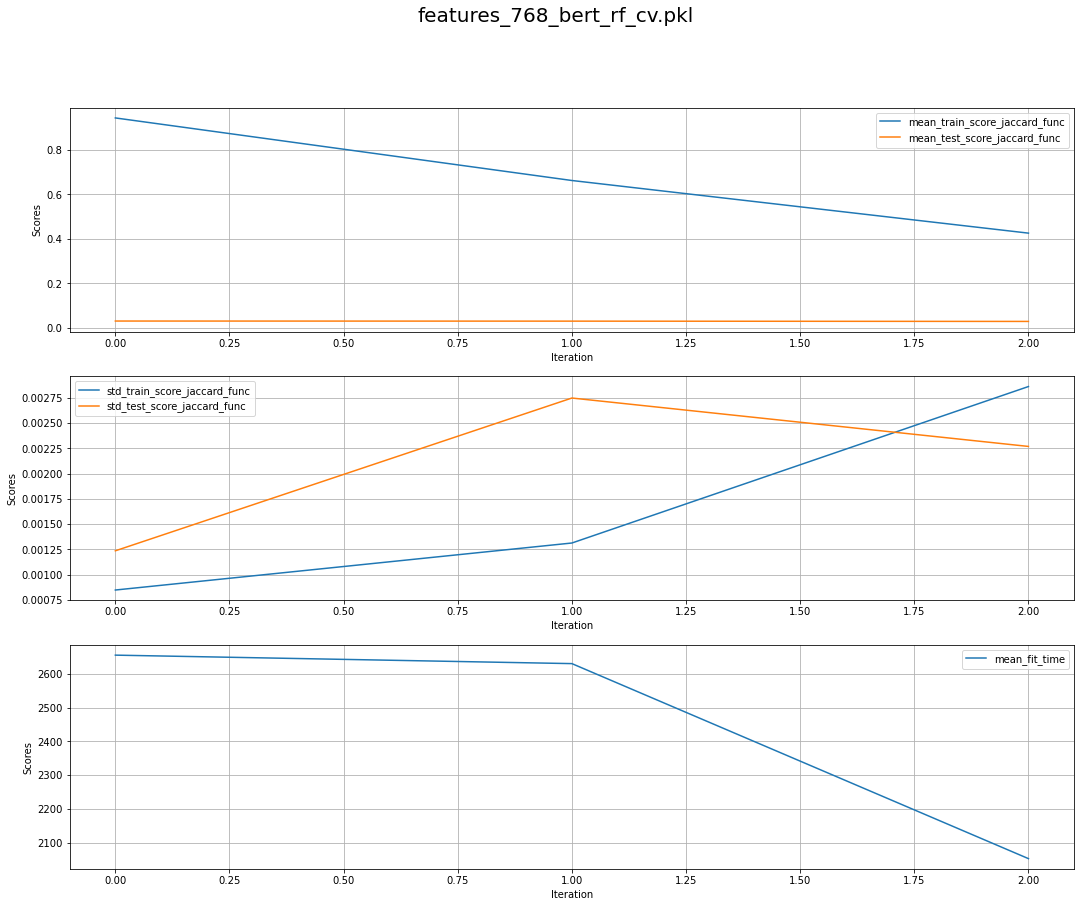

{'estimator__C': 0.7}
0.24307432169232338


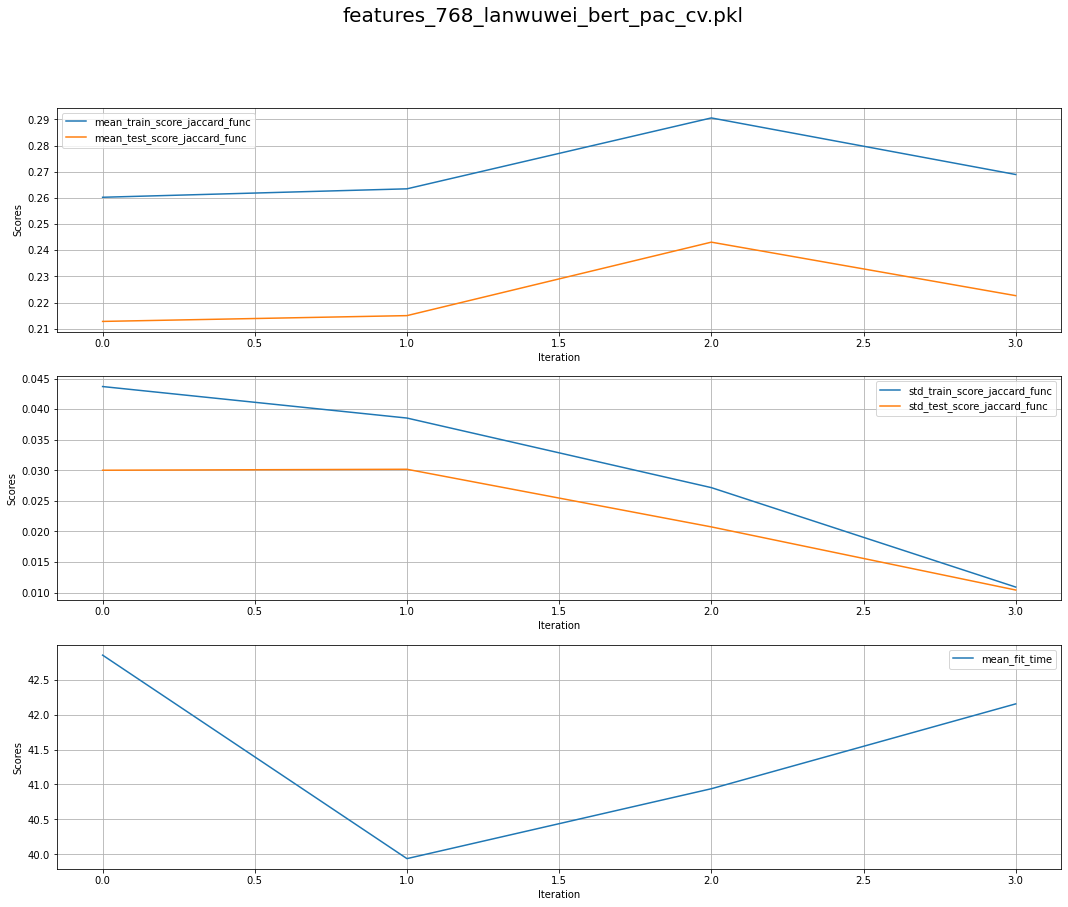

{'estimator__alpha': 0.5}
0.1688802839189617


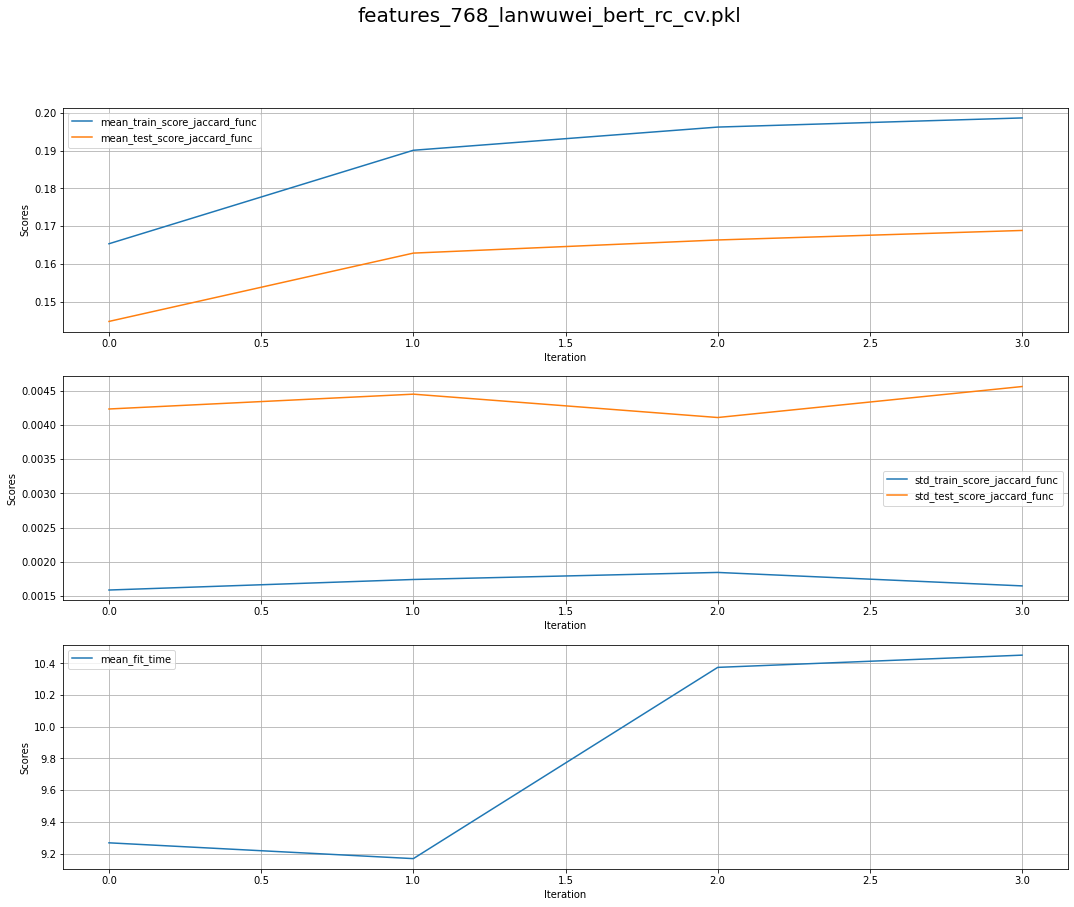

{'estimator__min_samples_leaf': 1}
0.008383121494755435


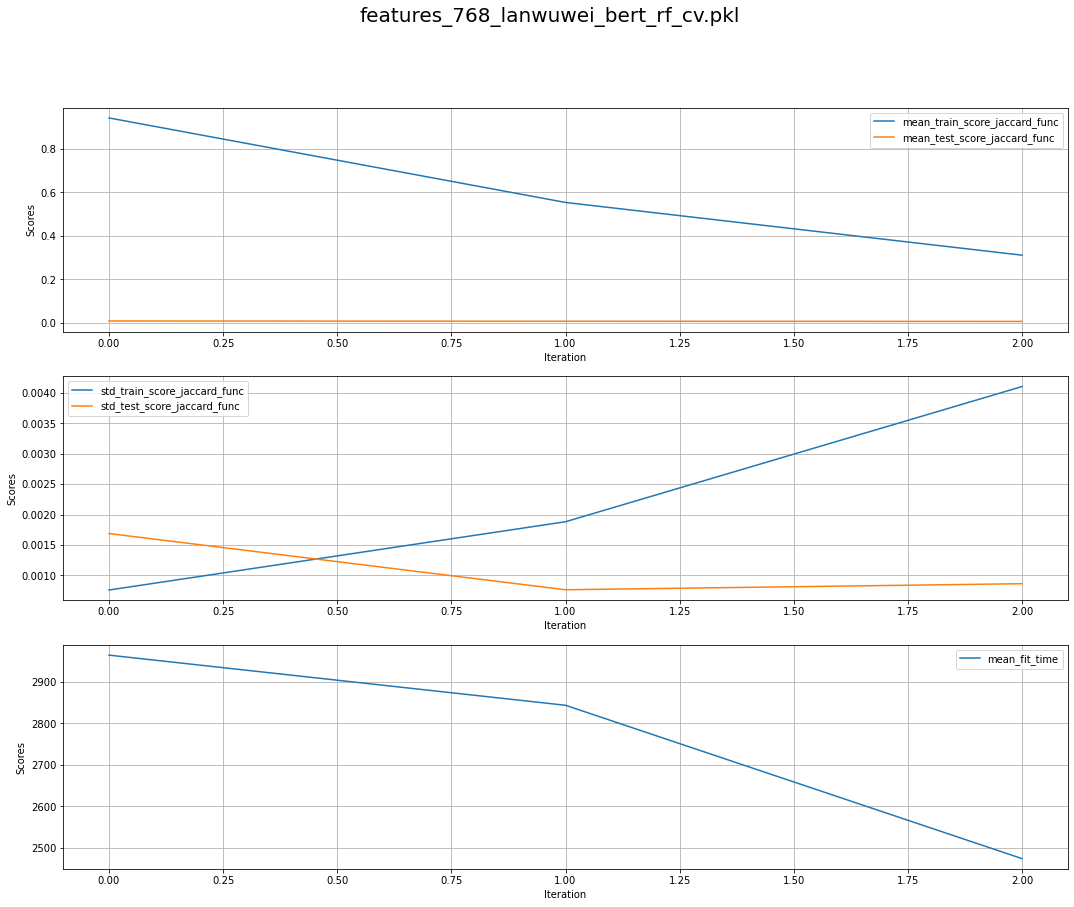

{'model_pac__estimator__C': 0.1, 'tfidf_input__max_df': 0.9, 'tfidf_input__min_df': 1}
0.48118070784454686


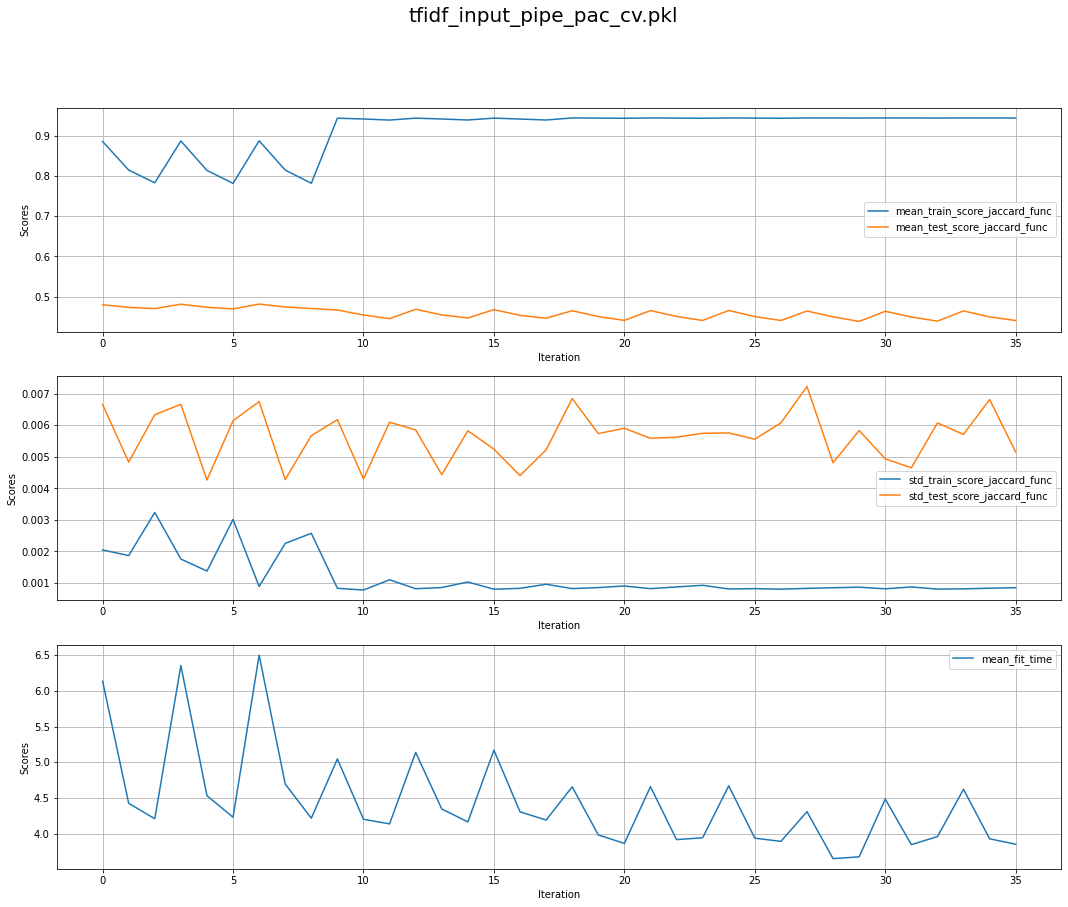

{'model_rc__estimator__alpha': 0.5, 'tfidf_input__max_df': 0.5, 'tfidf_input__min_df': 1}
0.40845009911010804


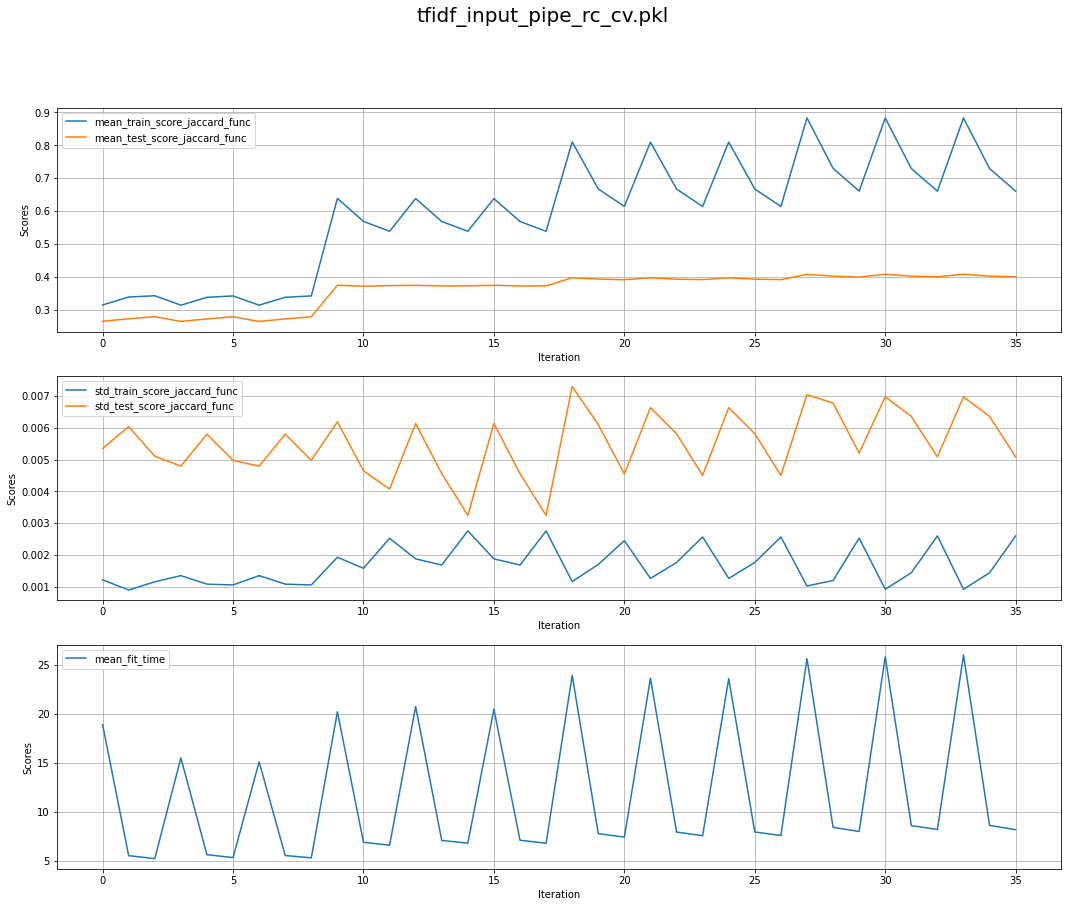

{'tfidf_input__max_df': 0.3, 'tfidf_input__min_df': 10}
0.3100162664805683


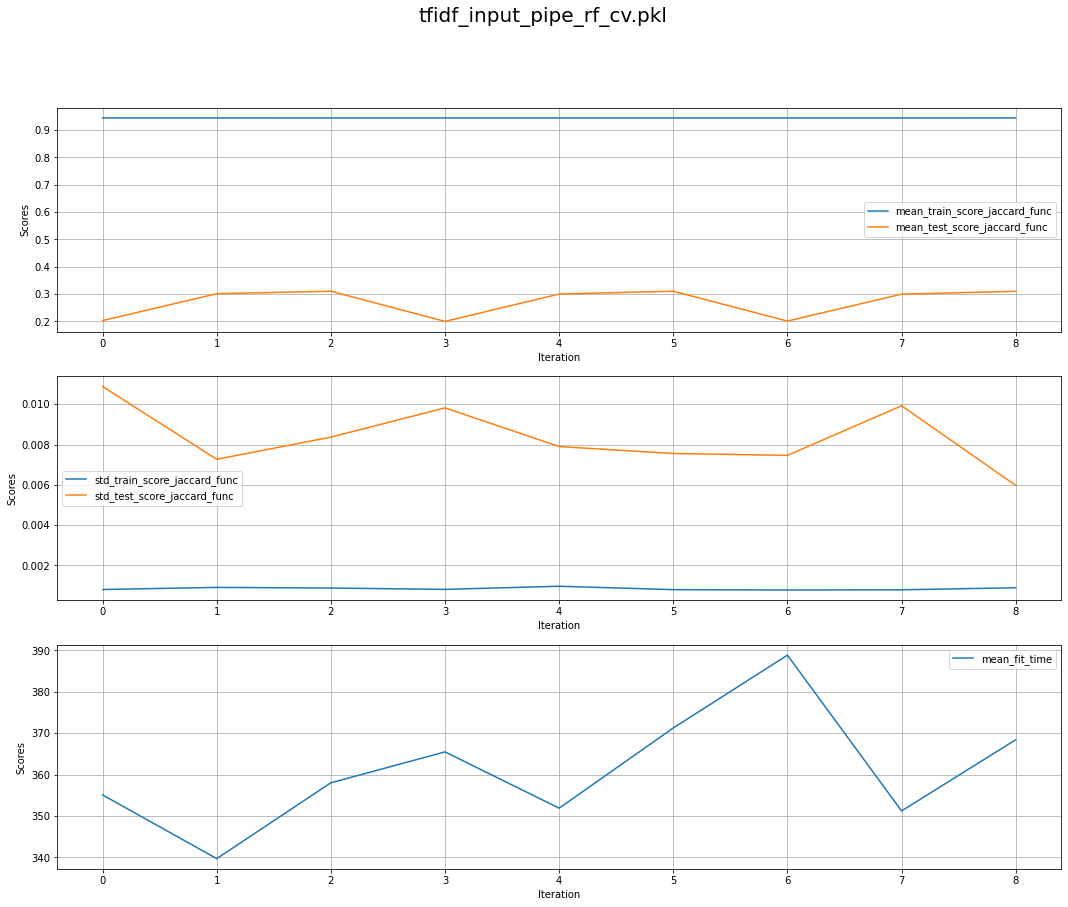

{'estimator__C': 0.4}
0.44159636925682033


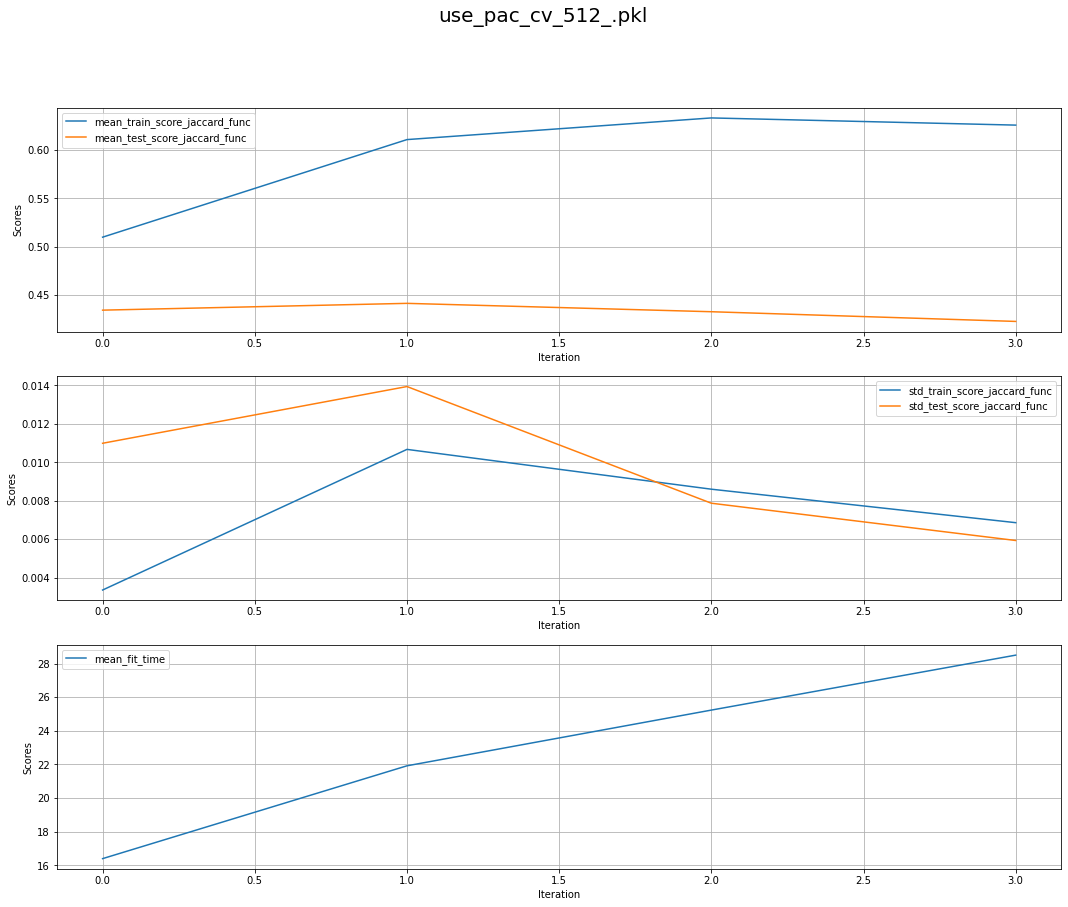

{'estimator__alpha': 0.5}
0.27946256710089445


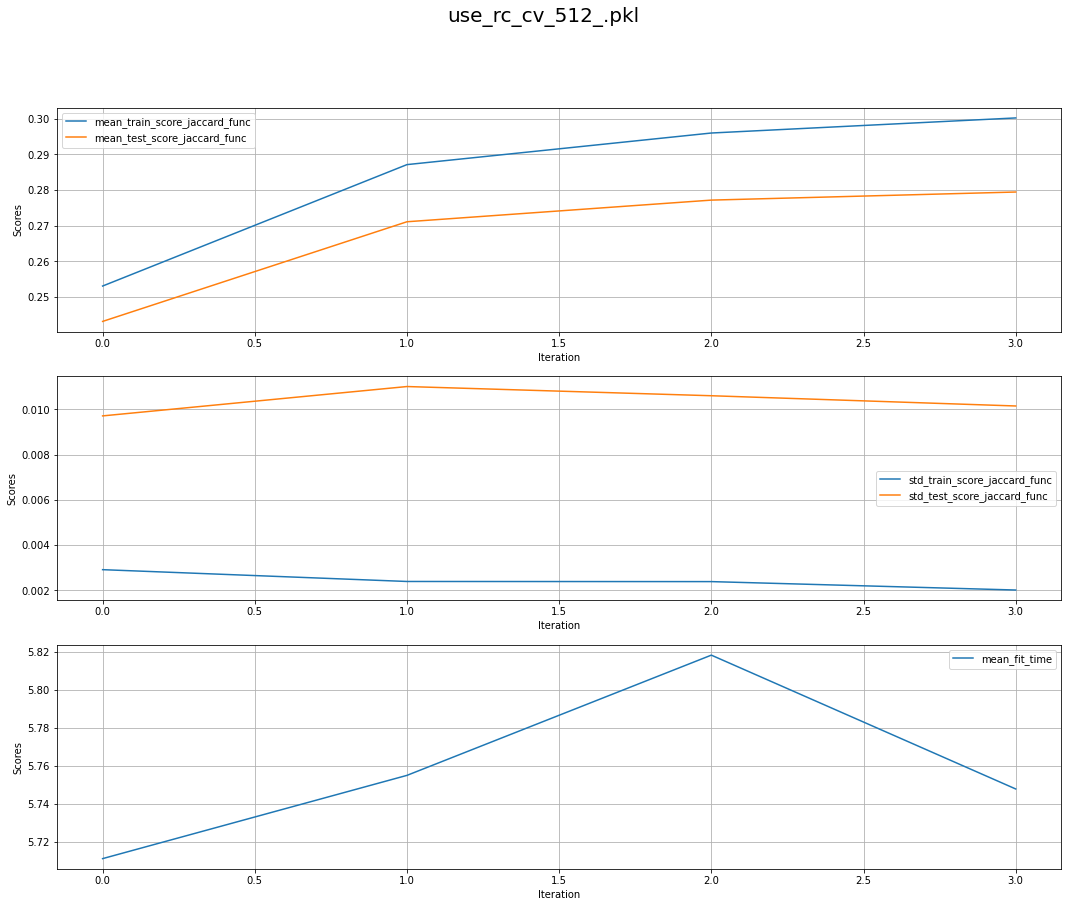

{'estimator__min_samples_leaf': 2}
0.24541393365498537


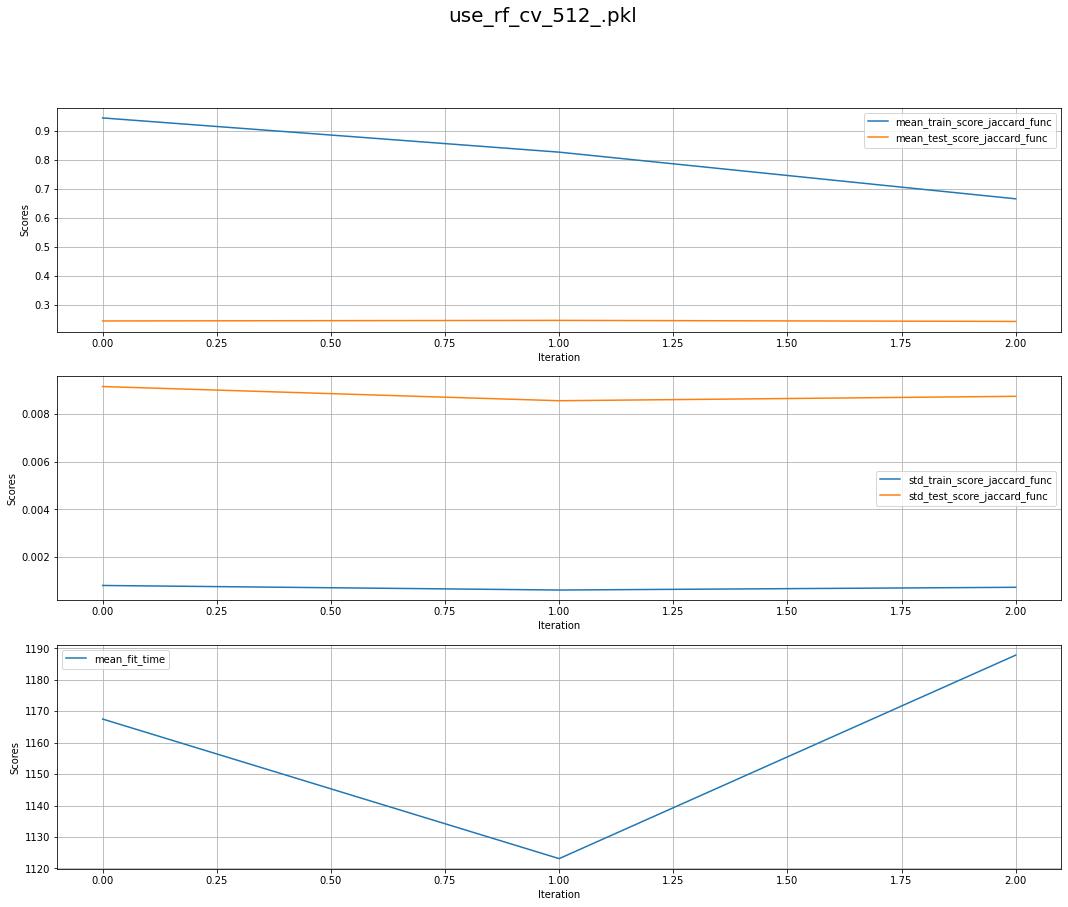

{'estimator__C': 0.7}
0.23763792578472373


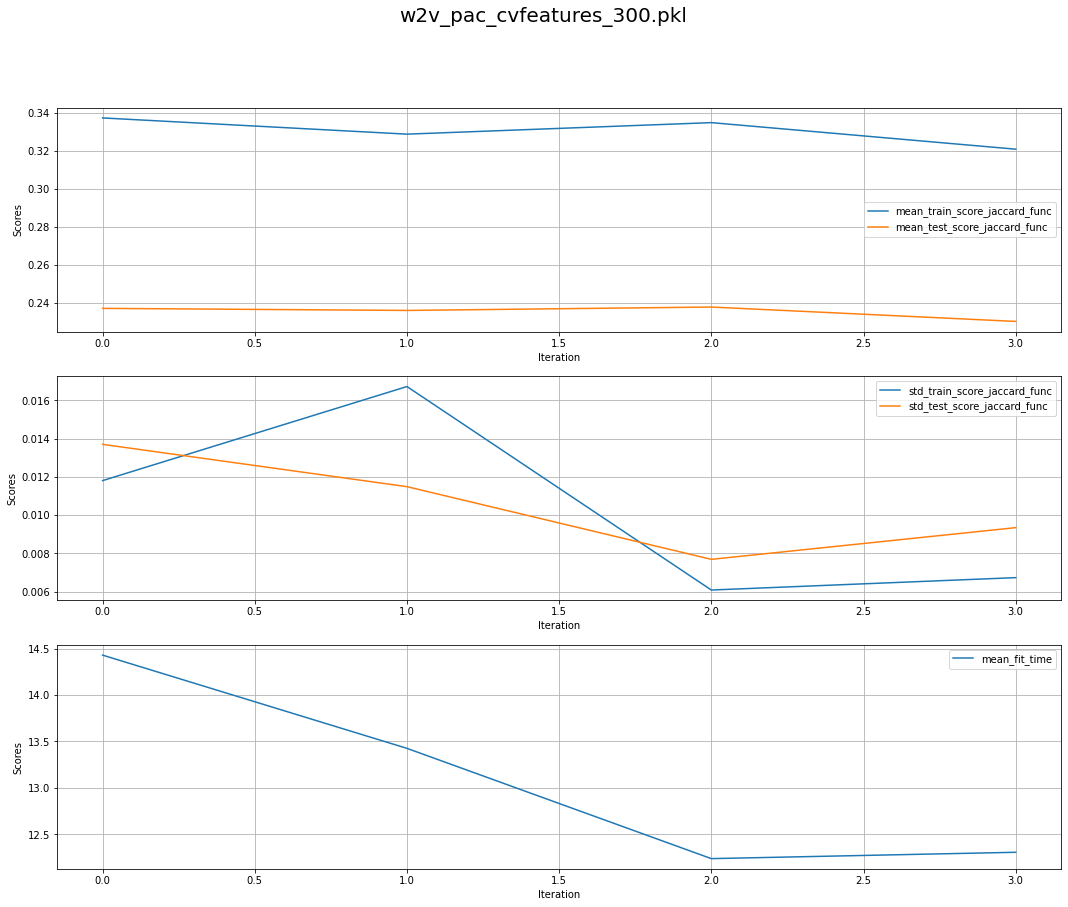

{'estimator__alpha': 0.7142857142857143}
0.13406212323783057


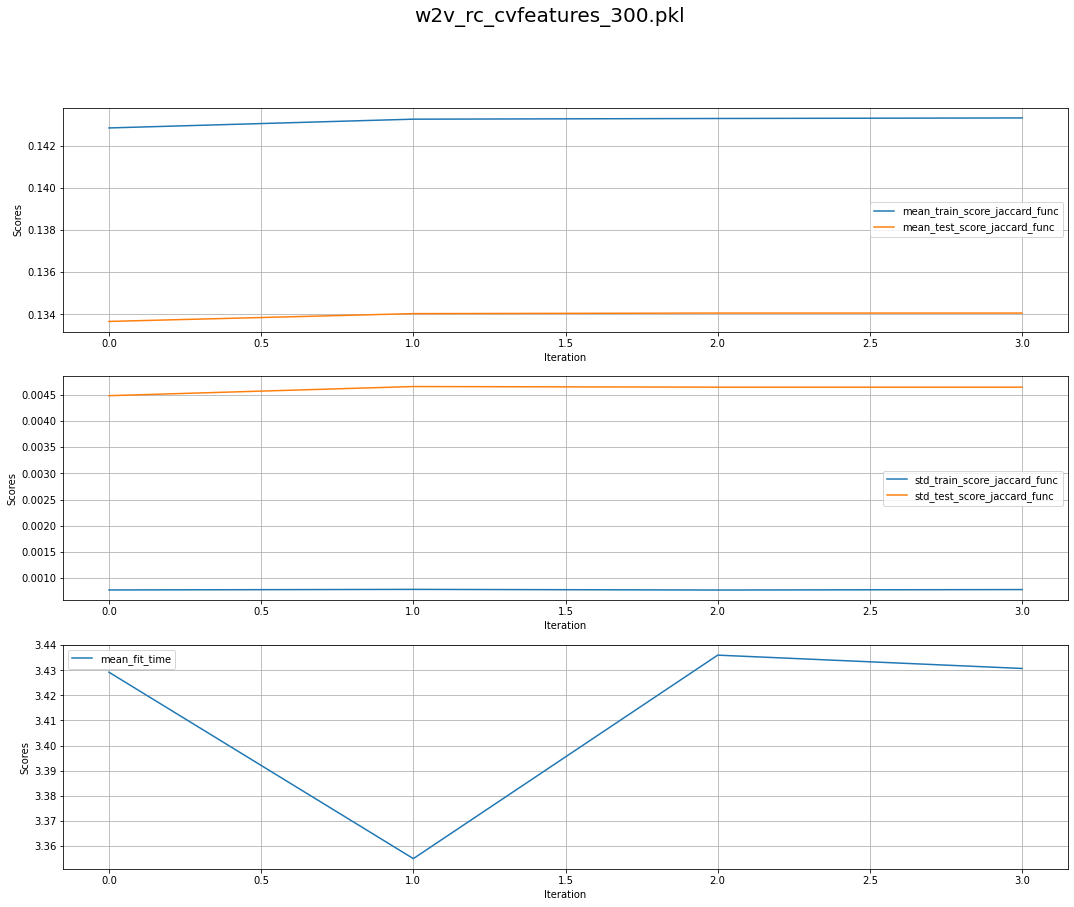

{'estimator__min_samples_leaf': 1}
0.055299425727032336


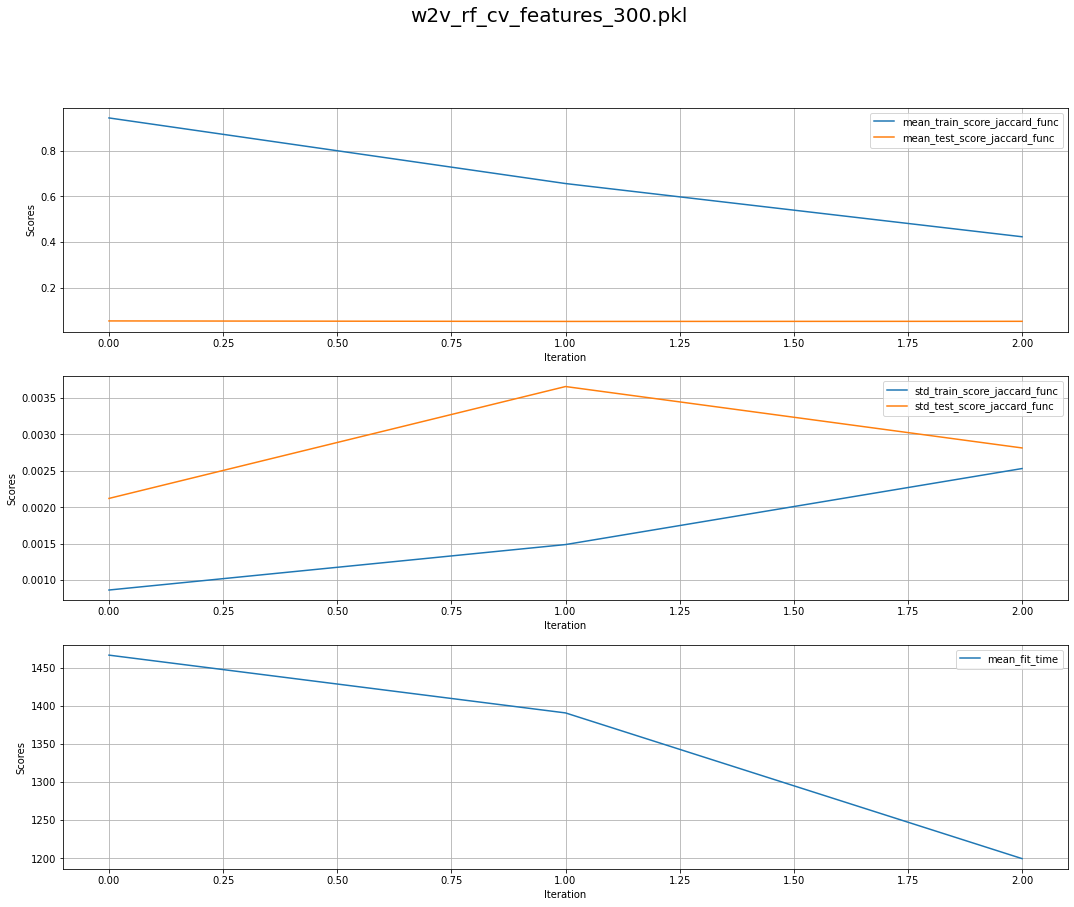

In [17]:
for i in range(0,len(estimator_list)):
#     print(str(i))
    print(estimator_list[i].best_params_)
    print(estimator_list[i].best_score_)
    plot_results2(estimator_list[i],directories[i],'score_jaccard_func')

# Etude du meilleur estimateur supervisé

On reprend ici notre étude avec le meilleur estimateur.  
On va d'abord récupérer son indice dans la liste des estimateurs:

In [18]:
idir_list = [idir == 'tfidf_input_pipe_pac_cv.pkl' for idir in directories]
# idir_list

In [19]:
idx=0
for idir in range(len(directories)):
#     print(idir)
    if idir_list[idir]:
        idx = idir
print(directories[idx])

tfidf_input_pipe_pac_cv.pkl


In [20]:
estimator_sup = estimator_list[idx].best_estimator_
estimator_sup

Pipeline(steps=[('tfidf_input', TfidfVectorizer(max_df=0.9)),
                ('model_pac',
                 MultiOutputClassifier(estimator=PassiveAggressiveClassifier(C=0.1)))])

On l'enregistre ici pour le déploiement ultérieur de l'API.

In [21]:
import joblib

joblib.dump(estimator_sup, 'D:\\Utilisateurs\\Damien\\Documents\\Test_code\\test_python\\OCR_projets\\IML\\P5_\\'+'estimator_sup'  + '.pkl')

['D:\\Utilisateurs\\Damien\\Documents\\Test_code\\test_python\\OCR_projets\\IML\\P5_\\estimator_sup.pkl']

On charge les entrées nettoyés sur lesquels ont a réalisé nos entraînements, dans le but de réaliser des essais de prédiction:

In [22]:
## Import des données brutes et analyse de leur architecture

path_local = r'D:\Utilisateurs\Damien\Documents\Test_code\test_python\OCR_projets\IML\P5_' #
# path_cloud = 

data_clean = pd.read_csv(path_local + r'\data_clean.csv',sep=",",low_memory=False)

# QueryResults
# QueryResults_2012

On remet en forme les données de type liste pour qu'elles soit exploitables dans nos algorithmes:

In [23]:
import ast
ast.literal_eval(data_clean['Tags_filtered'][0])

['google', 'ios', 'xcode']

In [24]:
data_clean['Tags_list'] = data_clean['Tags_filtered'].apply(lambda x : ast.literal_eval(x))
data_clean['Tags_list']

0                        [google, ios, xcode]
1                                          []
2                    [multithreading, python]
3                                          []
4                                          []
                         ...                 
15885    [net, studio, testing, unit, visual]
15886                   [apache, java, spark]
15887                        [video, windows]
15888                          [java, spring]
15889                              [c++, c++]
Name: Tags_list, Length: 15890, dtype: object

Ainsi que le même dataset de train et de test qu'on avait lors de la recherche par validation croisée (__random_state=0__ dans le model_selection):

In [27]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

Y = mlb.fit_transform(data_clean['Tags_list'])
tag_list_100 = mlb.classes_.tolist()
tag_list_100

['ajax',
 'algorithm',
 'amazon',
 'android',
 'angular',
 'angularjs',
 'apache',
 'api',
 'app',
 'arrays',
 'asp',
 'async',
 'asynchronous',
 'authentication',
 'await',
 'bash',
 'boot',
 'bootstrap',
 'build',
 'c++',
 'chrome',
 'cocoa',
 'code',
 'core',
 'css',
 'data',
 'database',
 'dataframe',
 'design',
 'django',
 'entity',
 'express',
 'file',
 'framework',
 'git',
 'google',
 'gradle',
 'hibernate',
 'html',
 'image',
 'interface',
 'ios',
 'iphone',
 'java',
 'javascript',
 'jpa',
 'jquery',
 'json',
 'laravel',
 'layout',
 'learning',
 'library',
 'linux',
 'machine',
 'macos',
 'memory',
 'multithreading',
 'mvc',
 'mysql',
 'net',
 'network',
 'node',
 'numpy',
 'objective',
 'opencv',
 'optimization',
 'pandas',
 'performance',
 'php',
 'postgresql',
 'processing',
 'python',
 'rails',
 'react',
 'reactjs',
 'rest',
 'ruby',
 'security',
 'server',
 'services',
 'shell',
 'spark',
 'spring',
 'sql',
 'ssl',
 'string',
 'studio',
 'swift',
 'testing',
 'touch',
 'tw

In [ ]:
# import joblib

# #load labels

# tag_list_100 = joblib.load('D:\\Utilisateurs\\Damien\\Documents\\Test_code\\test_python\\OCR_projets\\IML\\P5_\\'+'tag_list_100'  + '.pkl')
# tag_list_100

In [26]:
from sklearn import model_selection

X = data_clean['text_input']

X_train, X_test, Y_train, Y_test = model_selection.train_test_split(X, Y, test_size=0.2, random_state=0 ) # 20% des données dans le jeu de test # random_state = 1 pour avoir le même train-test set dans les autres jupyter notebooks

On récupère la liste des 100 tags les plus utilisés dans notre dataset.

On va ainsi définir plusieurs sous dataset:

In [28]:
# Y_true = Y
# Y_train_true = Y_train

In [29]:
Y_train_predicted = estimator_sup.predict(X_train)
Y_train_predicted

array([[0, 0, 1, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [30]:
# jaccard_func(Y_train, Y_train_predicted)

On évalue ici le score pour les données de test:

In [31]:
Y_test_predicted = estimator_sup.predict(X_test)
jaccard_func(Y_test, Y_test_predicted)

0.48234276823798533

On trouve un score du jaccard moyen de 0.48, qui est du même ordre que celui constaté pour le meilleur estimateur sur la validation croisée.  
Pour se rendre compte des tags prédits lors des questions données en entrée, on définie une fonction qui va nous sortir les tags prédit:

In [32]:
# Renvoie la liste des tags prédits par la matrice binaire y_pred à partir de la liste de tags prédéfinie
def find_tags(y_pred,tag_list_true):
    idx = 0
    tag_list_doc_ = []

    for idx in range((y_pred.shape[0])):
            idx_doc = np.where(y_pred[idx,:] == 1)
            test_tag = [tag_list_true[i] for i in idx_doc[0]]
            tag_list_doc_.append( test_tag )
    return tag_list_doc_

In [33]:
# # Renvoie la liste des tags prédits par un estimateur donné à partir d'une entrée de type sentence (String)
# def pred_tags(user_question, estimator):
#     user_question_cleaned = transform_bow_fct(user_question) # A redéfinir dans le notebook
    
#     y_pred = estimator.predict([user_question_cleaned])
    
#     tag_list_doc_pred = find_tags(y_pred, tag_list_100)
    
#     return tag_list_doc_pred

In [34]:
# user_question = ["how to install python"]
# pred_tags(user_question, estimator_sup)

In [35]:
# Exemple de texte
# text_in = "how to install python"
# text_in = "what is the best programming language ?"
# text_in = "Which programming language should i use to make a person recognition with camera?"
text_in = "java and ios"
y_pred = estimator_sup.predict([text_in])
find_tags(y_pred,tag_list_100)

[['ios', 'java']]

In [36]:
text_in = "how to install python"
find_tags(y_pred,tag_list_100)

[['ios', 'java']]

In [37]:
X_test

11582    cartesian product pandastwo pandas dataframes ...
9104     create view order clausetrying create view ord...
5890     get location text present image using opencvim...
13925    import importwondering difference code fragmen...
15785    bubble sort slower gccmade bubble sort impleme...
                               ...                        
15199    grid slick grid angular grid betterrecently th...
12440    center component mui make responsivequite unde...
8130     jquery parallax scrolling effect multi directi...
13994    compiler error msgfmt command foundtrying upda...
15483    using java referencequeuesoftreference weakref...
Name: text_input, Length: 3178, dtype: object

In [38]:
X_test.iloc[0]

'cartesian product pandastwo pandas dataframes pandas import dataframe df1 dataframe col1 1,2 col2 3,4 df2 dataframe col3 5,6 best practice get cartesian product course without writing explicitly like df1 df2 cartesian product cartesian dataframe col1 1,2,1,2 col2 3,4,3,4 col3 5,5,6,6'

In [39]:
y_pred = estimator_sup.predict([X_test.iloc[0]])
find_tags(y_pred,tag_list_100)

[['dataframe', 'pandas', 'python']]

In [41]:
# # Problèmes d'indexes résultant d'un problème sur tab_tag_pred_test
# y_pred = Y_test_predicted
# tab_tag_pred_test = pd.DataFrame(find_tags(y_pred,tag_list_100))
# pd.concat([X_test,tab_tag_pred_test],axis=1).head(50)

In [42]:
# tab_tag_pred_test

In [43]:
XY_test = pd.DataFrame(X_test)
XY_test['Y_test_pred'] = find_tags(Y_test_predicted,tag_list_100)
XY_test['Y_test_pred_len'] = [ len(value) for value in XY_test['Y_test_pred']]
XY_test.head(50)

,text_input,Y_test_pred,Y_test_pred_len
11582,cartesian product pandastwo pandas dataframes ...,"[dataframe, pandas, python]",3
9104,create view order clausetrying create view ord...,"[server, sql]",2
5890,get location text present image using opencvim...,[image],1
13925,import importwondering difference code fragmen...,[python],1
15785,bubble sort slower gccmade bubble sort impleme...,"[optimization, performance, x]",3
8207,ios breaks geolocation webapps apple mobile we...,"[ios, iphone, web]",3
4708,store tokens cookies localstorage sessionusing...,"[authentication, express]",2
6983,make new list property object another listimag...,[],0
8449,copying global clipboard work java ubuntufollo...,[java],1
5571,capturing single image webcam java pythonwant ...,[],0


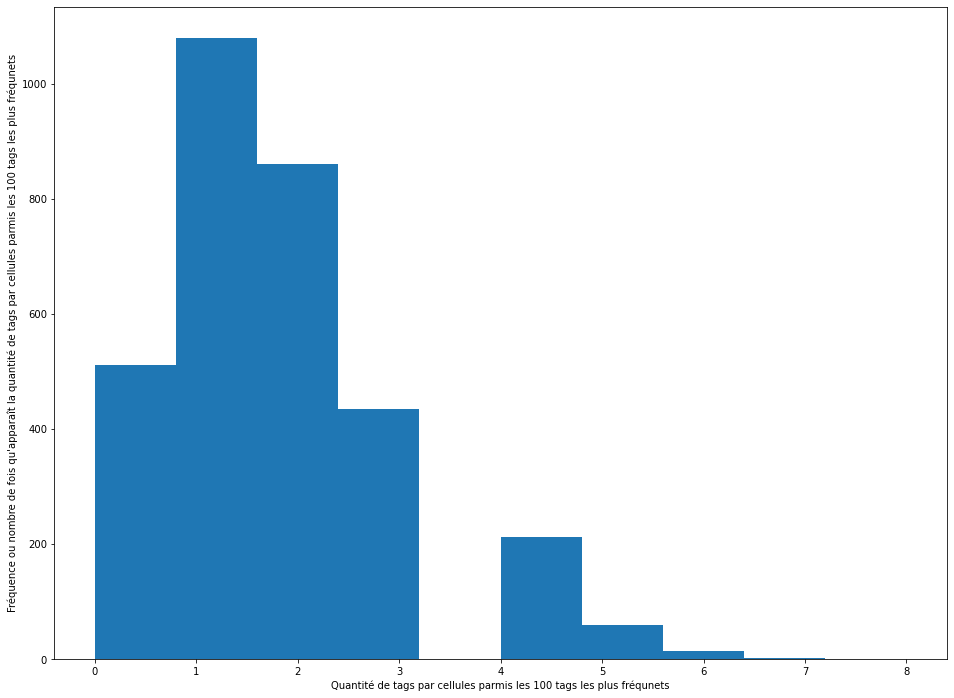

In [44]:
XY_test['Y_test_pred_len'].plot.hist(figsize=(16,12))
plt.ylabel("Fréquence ou nombre de fois qu'apparaît la quantité de tags par cellules parmis les 100 tags les plus fréqunets")
plt.xlabel("Quantité de tags par cellules parmis les 100 tags les plus fréqunets")
plt.show()

Bien que le score se rapproche de celui d'entraînement, il semble qu'il y ait une quantité non négligeable de phrases dont aucun tags n'a été trouvé (500/3178 phrases), malgré certains mots clés dans "text_input" qui révèleraient le contraire.  

On pourrait retravailler la procédure de prétraitement de texte en amont ainsi que le choix des stopwords.  

On pourrait aussi supposer que durant la procédure de TF-IDF, les paramètres {min_df, max_df} qui représentent la quantité de termes ignorées selon leur fréquence faible ou élevée ont peut-être été trop fort.  

tfidf_input_pipe_pac_cv.pkl best parameters are: {'model_pac__estimator__C': 0.1, 'tfidf_input__max_df': 0.9, 'tfidf_input__min_df': 1}

In [45]:
# pd.DataFrame(find_tags(Y_test_predicted,tag_list_100))

# Analyse de la répartition des tags
Evaluons les tags les pllus intéressant:

On crée une fonction pour créer rapidement les dictionnaires des fréquences des tags:

In [46]:
import nltk
def dict_pred(y_pred,tag_list_100):
    list_pred = find_tags(y_pred,tag_list_100) # Crée une liste de liste de tags prédit
    list_tags_total = []
    for i in range(len(list_pred)):
        list_tags_total.extend(list_pred[i]) # Crée la liste ttoale des tags (qui peuvent se répéter)
    freq_tags = nltk.FreqDist(list_tags_total)
    return freq_tags

In [47]:
freq_tags_test = dict_pred(Y_test,tag_list_100)
freq_tags_test

FreqDist({'python': 453, 'ios': 378, 'javascript': 358, 'java': 334, 'android': 312, 'net': 208, 'html': 167, 'c++': 161, 'node': 147, 'asp': 139, ...})

In [48]:
len(freq_tags_test)

100

In [49]:
sum(freq_tags_test.values())

7527

In [50]:
freq_tags_test_pred = dict_pred(Y_test_predicted,tag_list_100)
freq_tags_test_pred

FreqDist({'python': 405, 'ios': 329, 'javascript': 311, 'android': 294, 'java': 275, 'net': 192, 'c++': 134, 'html': 120, 'asp': 116, 'node': 109, ...})

In [51]:
len(freq_tags_test_pred)

98

In [52]:
sum(freq_tags_test_pred.values())

5367

On remarque que 5367/7527 = 71% de tags ont été prédit au total sur le dataset de test. Et le jaccard score de 0.48 nous indiquerait que seuelement 50% de ces tags prédits sembles correctes.  
On pourrait visualiser la fréquence des tags les mieux répertoriés grâce à la librairie nltk:

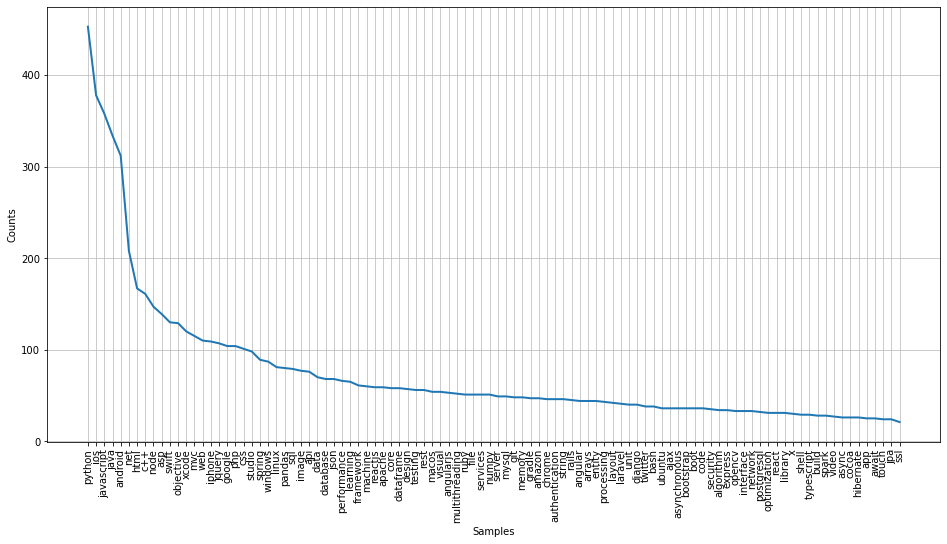

In [53]:
# Tracé des 100 mots les plus fréquents
plt.figure(figsize=(16,8))
freq_tags_test.plot(100)
plt.show()

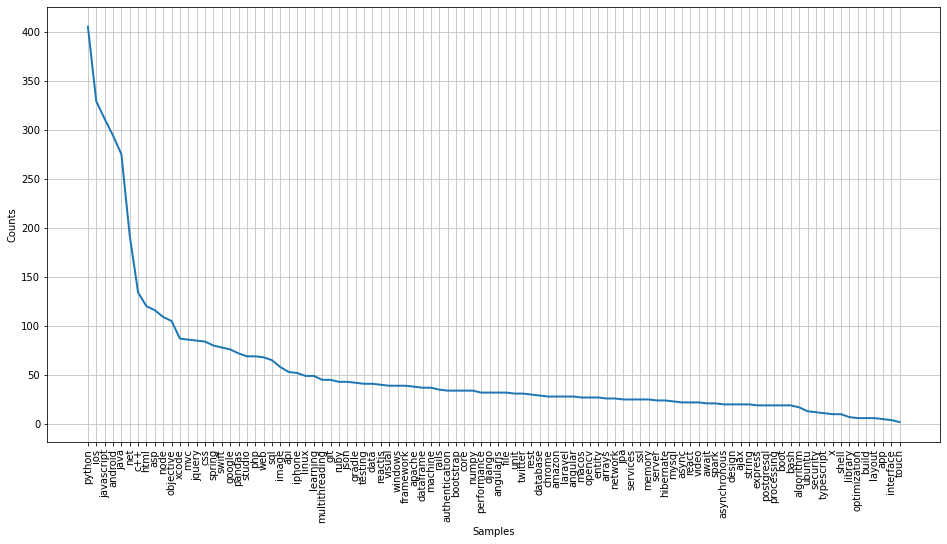

In [54]:
# Tracé des 100 mots les plus fréquents
plt.figure(figsize=(16,8))
freq_tags_test_pred.plot(100)
plt.show()

In [55]:

# plt.figure(figsize=(16,16))
# plt.plot(list(freq_tags_test.keys()),list(freq_tags_test.values()))
# plt.plot(list(freq_tags.keys()),list(freq_tags.values()))

## illisible

On crée une fonction de création rapide de ces listes pour les tracer ensuite leur visualisation:

In [56]:
def freq_list_plot(freq_tags_dict):
    res = dict((v,k) for k,v in freq_tags_dict.items()) # On inverse le rôle des valeurs et clés du dictionnaire
    myList = res.items()
    myList = sorted(myList) # On trie les listes selon les valurs les plus élevées de fréquences
    x_values, y_keys = zip(*myList)
    return [x_values, y_keys]

In [57]:
freq_tags_test = dict_pred(Y_test,tag_list_100)
[x_values_test, y_keys_test] = freq_list_plot(freq_tags_test)

In [58]:
freq_tags_test_pred = dict_pred(Y_test_predicted,tag_list_100)
[x_values_test_pred, y_keys_test_pred] = freq_list_plot(freq_tags_test_pred)

On visualise ainsi les données de test.

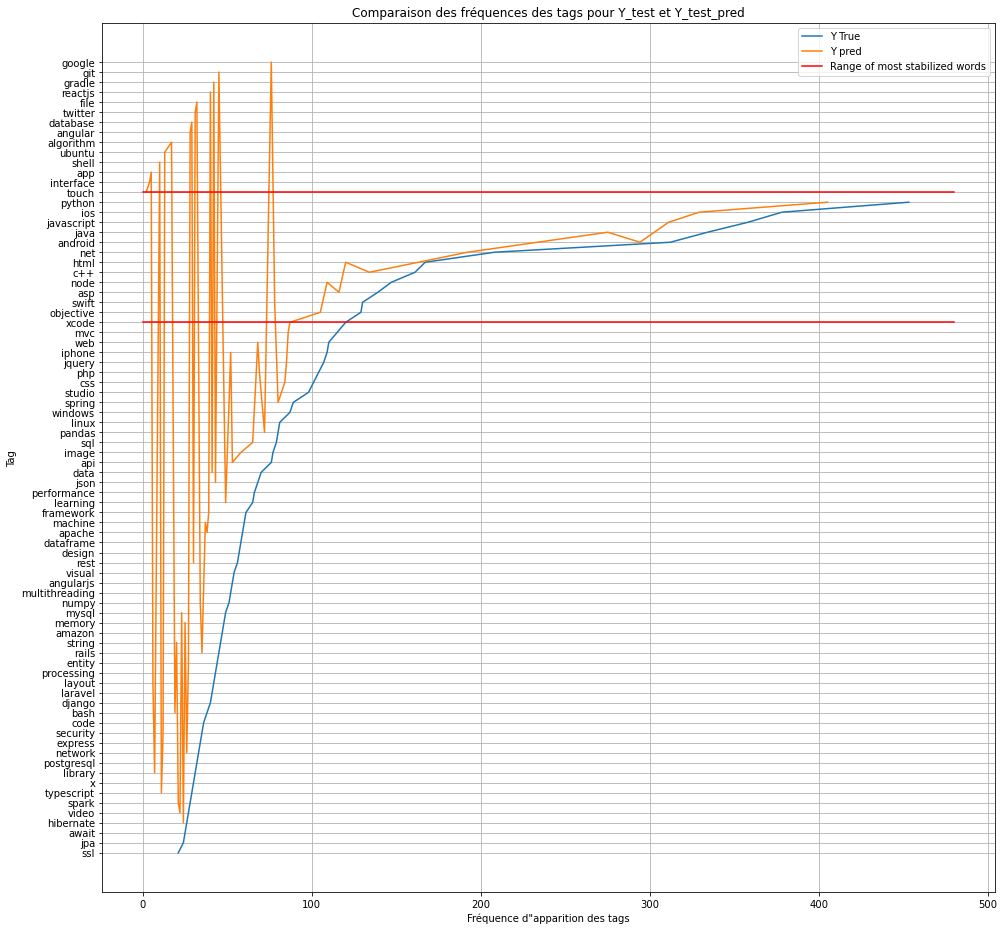

In [59]:
plt.figure(figsize=(16,16))
plt.title("Comparaison des fréquences des tags pour Y_test et Y_test_pred")
plt.plot(x_values_test, y_keys_test)
plt.plot(x_values_test_pred, y_keys_test_pred)
plt.plot([0,480],["xcode","xcode"],color='r')
plt.plot([0,480],["touch","touch"],color='r')
plt.legend(["Y True", "Y pred","Range of most stabilized words"])
plt.xlabel('Fréquence d"apparition des tags')
plt.ylabel('Tag')
plt.grid()
plt.show()

On peut visualiser par curiosité le graphe généré par celui des données entraînées.

In [60]:
freq_tags_train = dict_pred(Y_train,tag_list_100)
[x_values_train, y_keys_train] = freq_list_plot(freq_tags_train)

In [61]:
freq_tags_train_pred = dict_pred(Y_train_predicted,tag_list_100)
[x_values_train_pred, y_keys_train_pred] = freq_list_plot(freq_tags_train_pred)

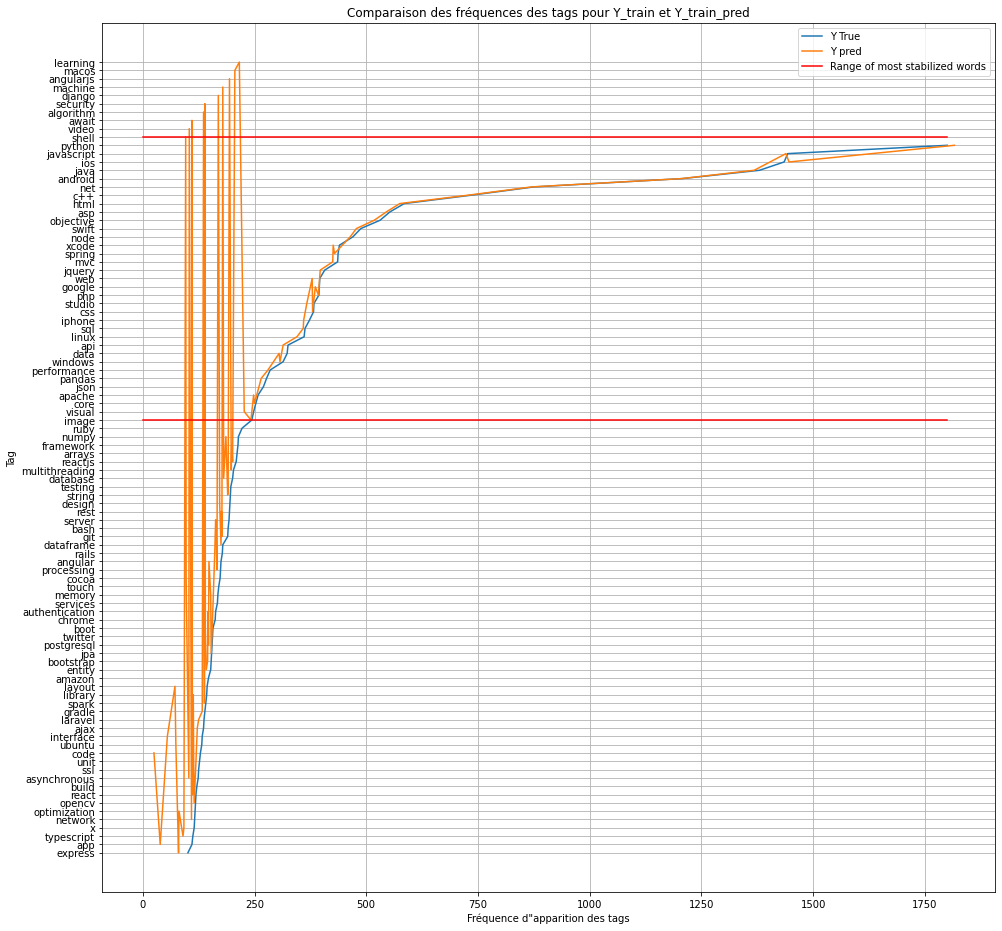

In [62]:
plt.figure(figsize=(16,16))
plt.title("Comparaison des fréquences des tags pour Y_train et Y_train_pred")
plt.plot(x_values_train, y_keys_train)
plt.plot(x_values_train_pred, y_keys_train_pred)
plt.plot([0,1800],["image","image"],color='r')
plt.plot([0,1800],["shell","shell"],color='r')
plt.legend(["Y True", "Y pred","Range of most stabilized words"])
plt.xlabel('Fréquence d"apparition des tags')
plt.ylabel('Tag')
plt.grid()
plt.show()

Ces graphes tendent à montrer que certains tags prédit semblent stables avec les tags réels. Cependant, même si des tags sont prédit avec le même effectif que les tags réels au sein du dataset global, celà ne veut pas dire qu'ils ont été prédits dans le même document (ex: le même nombre d'assignation pour un tag en global pour le Y réel et le Y prédit, avec 50 répartis sur plusieurs documents en Y_réel, et 50 dans un seul document pour le Y prédit).  
Pour s'assurer de cette bonne ou mauvaise correspondance entre les tags, on pourrait utiliser d'autres types de mesures de bonnes classifications, notamment la précision et le recall.

In [63]:
from sklearn.metrics import classification_report
print(classification_report(Y_test, Y_test_predicted))

              precision    recall  f1-score   support

           0       0.90      0.50      0.64        36
           1       0.82      0.41      0.55        34
           2       0.89      0.53      0.67        47
           3       0.92      0.87      0.89       312
           4       0.75      0.48      0.58        44
           5       0.91      0.55      0.68        53
           6       0.89      0.58      0.70        59
           7       0.74      0.51      0.60        76
           8       0.80      0.16      0.27        25
           9       0.65      0.39      0.49        44
          10       0.87      0.73      0.79       139
          11       0.86      0.73      0.79        26
          12       0.80      0.44      0.57        36
          13       0.56      0.41      0.47        46
          14       0.90      0.76      0.83        25
          15       0.79      0.39      0.53        38
          16       0.89      0.47      0.62        36
          17       0.94    

C:\Users\daims\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\daims\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\daims\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Il semble qu'il y est une majorité de grande précision devant des recall moyens.  
Traçons graghiquement ces résultats.

In [64]:
from sklearn.metrics import PrecisionRecallDisplay

In [65]:
y_score = Y_test_predicted

In [66]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

n_classes = Y.shape[1] #100

# For each class
precision = dict()
recall = dict()
average_precision = dict()
for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(Y_test[:, i], y_score[:, i])
    average_precision[i] = average_precision_score(Y_test[:, i], y_score[:, i])

# A "micro-average": quantifying score on all classes jointly
precision["micro"], recall["micro"], _ = precision_recall_curve(
    Y_test.ravel(), y_score.ravel()
)
average_precision["micro"] = average_precision_score(Y_test, y_score, average="micro")

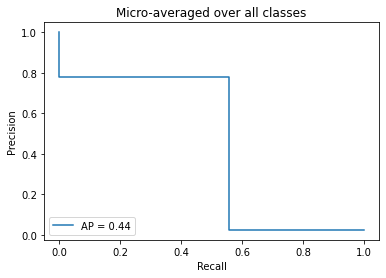

In [67]:
display = PrecisionRecallDisplay(
    recall=recall["micro"],
    precision=precision["micro"],
    average_precision=average_precision["micro"],
)
display.plot()
_ = display.ax_.set_title("Micro-averaged over all classes")
plt.show()
# plt.figure(figsize=(18,14))

On constate que Precison est nulle lorsque le recall est supérieur à 0.58. On ne prédit que 58% de résultats. Lorsque ces résultats sont prédits, la précisions est entre 0.8 et 1. La précision est donc très bonne lorsqu'on prédit un tags. ET si l'on n eprédit pas de tags, c'est parce que la précision attendue aura tendance à être mauvaise. Dans ce cas, on préférera ne rien prédire.  
Cette approche est n'est pas nécesairement la meilleure dans notre contexte. En effect, un utilisateur pourrait se sentir frustré de n'avaoir aucune prédiction, plutôt que d'avoir toujours des prédictions même si elles ne sont pas correctes (pas une bonne précision mais un plus grand recall). Pour ce faire, il aurait fallu changer la métrique de score employée (Jaccard) par une métrique moins pénalisante au recall (donc moins symétrique).  
Dans un autre contexte, par exemple dans de l'analyse d'image, il serait au contraire plus judicieux de ne prédire ce que l'on voit sur une image seuleemnt si l'on est sûr (donc une précision bonne).

On peut retranscrire la matrice des prédictions avc les tags par document:

In [68]:
# column names
tagsnames = ["tag_" + str(i) for i in range(1,Y_train_predicted.shape[1]+1)]

# index names
docnames = ["doc_" + str(i) for i in range(len(Y_train_predicted))]

# Make the pandas dataframe
df_doc_tags_sup = pd.DataFrame(Y_train_predicted, columns=tagsnames, index=docnames)

# # Get dominant topic for each document
# dominant_topic = np.argmax(df_doc_topic_tfidf.values, axis=1)
# df_doc_topic_tfidf['dominant_topic'] = dominant_topic


In [69]:
df_doc_tags_sup

,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,tag_9,tag_10,...,tag_91,tag_92,tag_93,tag_94,tag_95,tag_96,tag_97,tag_98,tag_99,tag_100
doc_0,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
doc_1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
doc_2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
doc_3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
doc_4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
doc_12707,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
doc_12708,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
doc_12709,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
doc_12710,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Approche Non Supervisée
## Etude de l'approche LDA
Etant donné qu'on a choisist de catégoriser les questions sur 100 tags, on va utiliser une approche automatique pour réaliser la correspondance entre les approches supervisées et non supervisées.

In [70]:
# This would print all the files and directories
estimator_lda_list = []
for file in directories_lda:
    print(file)
    estimator = joblib.load(path_gen_lda + "/" + file)
    estimator_lda_list.append(estimator)

pipe_cvect_input_lda_cv.pkl
pipe_tfidf_input_lda_cv.pkl


In [71]:
i_lda = 0
# 0: cvect
# 1: tf-idf
print(directories_lda[i_lda])

pipe_cvect_input_lda_cv.pkl


In [72]:
pipe_lda = estimator_lda_list[i_lda].best_estimator_

vectorizer_ = pipe_lda[0]
lda = pipe_lda[1]

X_train_trf = vectorizer_.fit_transform(X_train) # data_vectorized

Y_pred_lda = pipe_lda.transform(X_train)


In [73]:
# column names
topicnames = ["topic_" + str(i) for i in range(1,lda.n_components+1)]

# index names
docnames = ["doc_" + str(i) for i in range(len(X_train))]

# Make the pandas dataframe
df_doc_topic = pd.DataFrame(np.round(Y_pred_lda, 2), columns=topicnames, index=docnames)

# Get dominant topic for each document
dominant_topic = np.argmax(df_doc_topic.values, axis=1)+1  # +1 si on commence par topic_1 au lieu de topic_0
df_doc_topic['dominant_topic'] = dominant_topic


In [74]:
df_doc_topic

,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9,topic_10,...,topic_92,topic_93,topic_94,topic_95,topic_96,topic_97,topic_98,topic_99,topic_100,dominant_topic
doc_0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.0,0.01,...,0.0,0.00,0.00,0.12,0.00,0.0,0.0,0.0,0.00,30
doc_1,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.24,0.0,0.01,...,0.0,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.00,55
doc_2,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.93,0.0,0.00,...,0.0,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.00,8
doc_3,0.00,0.0,0.0,0.09,0.0,0.0,0.00,0.00,0.0,0.00,...,0.0,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.00,55
doc_4,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.0,0.00,...,0.0,0.41,0.00,0.00,0.00,0.0,0.0,0.0,0.00,93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
doc_12707,0.00,0.0,0.0,0.00,0.0,0.0,0.03,0.00,0.0,0.00,...,0.0,0.00,0.04,0.00,0.00,0.0,0.0,0.0,0.02,86
doc_12708,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.0,0.00,...,0.0,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.00,79
doc_12709,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.0,0.00,...,0.0,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.00,15
doc_12710,0.02,0.0,0.0,0.00,0.0,0.0,0.00,0.16,0.0,0.00,...,0.0,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.00,79


In [75]:
df_doc_topic_distribution = df_doc_topic['dominant_topic'].value_counts().reset_index(name="nb_doc")
df_doc_topic_distribution.columns = ['topic_name', 'nb_doc']
df_doc_topic_distribution

,topic_name,nb_doc
0,65,3306
1,79,1856
2,86,740
3,8,627
4,33,520
...,...,...
61,93,1
62,22,1
63,17,1
64,35,1


<Figure size 432x288 with 0 Axes>

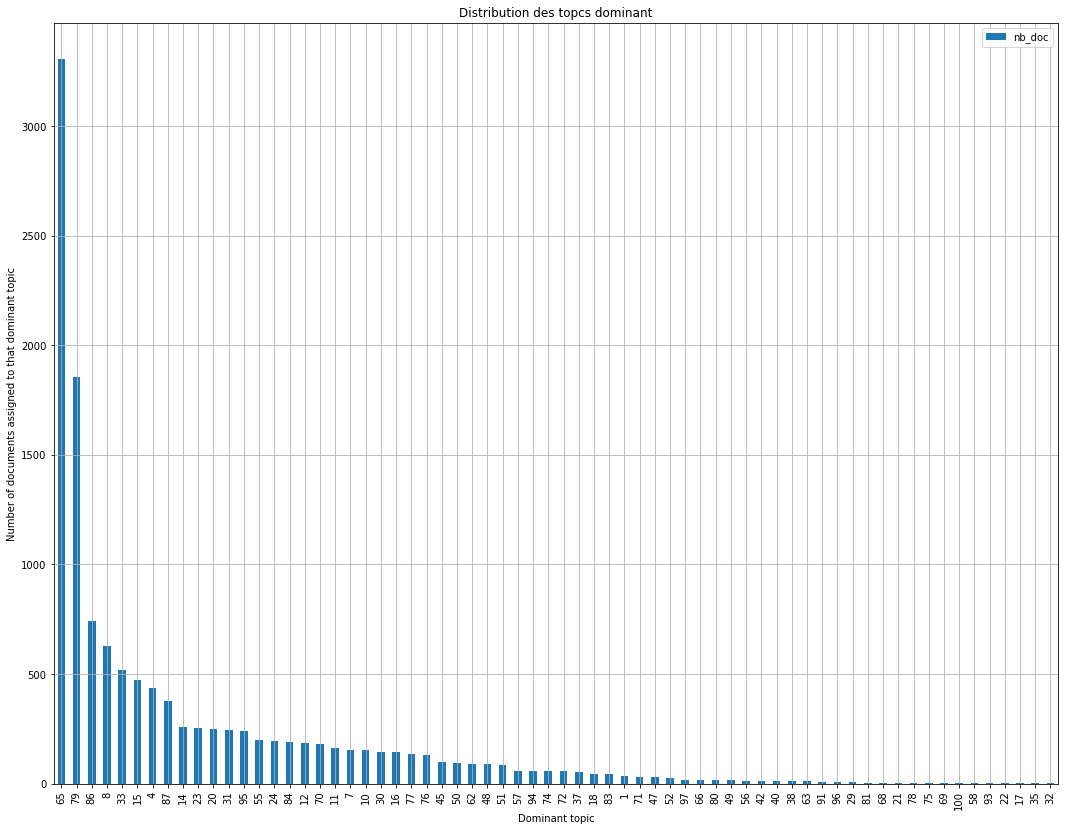

In [76]:
plt.figure()
df_doc_topic_distribution.plot.bar(x='topic_name',y='nb_doc',figsize=(18,14))
plt.title('Distribution des topcs dominant')
plt.xlabel("Dominant topic")
plt.ylabel("Number of documents assigned to that dominant topic")
plt.grid()
plt.show()

In [77]:
#vis
import pyLDAvis
import pyLDAvis.sklearn

In [78]:
pyLDAvis.enable_notebook()
lda_panel = pyLDAvis.sklearn.prepare(lda, X_train_trf ,  estimator_lda_list[i_lda].best_estimator_[0], mds='tsne')
lda_panel

C:\Users\daims\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)
C:\Users\daims\AppData\Roaming\Python\Python38\site-packages\pyLDAvis\_prepare.py:247: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
  default_term_info = default_term_info.sort_values(
C:\Users\daims\anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\daims\anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\daims\anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:819:

PreparedData(topic_coordinates=               x          y  topics  cluster       Freq
topic                                                  
64     33.622128  17.593376       1        1  14.504055
78     31.814373  24.318762       2        1  10.428042
85     35.076450  35.890007       3        1   4.914241
7      26.737282  12.382127       4        1   4.206919
3       4.449787  43.104095       5        1   3.617477
...          ...        ...     ...      ...        ...
53     -0.694502   3.005470      96        1   0.009997
33      2.026727  -6.593783      97        1   0.009997
42    -25.744139 -11.573689      98        1   0.009997
66    -12.168198  -2.352928      99        1   0.009997
26    -19.219082  -6.198939     100        1   0.009997

[100 rows x 5 columns], topic_info=              Term         Freq        Total  Category  logprob  loglift
2256          file  7315.000000  7315.000000   Default  30.0000  30.0000
310            app  6161.000000  6161.000000   Default  29.0000  29.0000
1459          data  7339.000000  7339.000000   Default  28.0000  28.0000
3226          java  6387.000000  6387.000000   Default  27.0000  27.0000
6130          time  3576.000000  3576.000000   Default  26.0000  26.0000
...            ...          ...          ...       ...      ...      ...
3296          keys     0.018268   453.769444  Topic100  -8.8274  -0.9095
2500      generate     0.018265   535.796104  Topic100  -8.8276  -1.0759
3077  instructions     0.018264   236.799218  Topic100  -8.8277  -0.2594
2082    executable     0.018262   229.639904  Topic100  -8.8277  -0.2288
4262          pair     0.018262   114.240988  Topic100  -8.8278   0.4694

[5521 rows x 6 columns], token_table=      Topic      Freq        Term
term                             
0        19  0.981058          00
1         1  0.196454         000
1         4  0.017083         000
1         6  0.119581         000
1        17  0.657695         000
...     ...       ...         ...
6834     34  0.675572        zoom
6836     22  0.051219     zooming
6836     34  0.921945     zooming
6837      3  0.979573         zsh
6838     12  0.990478  zygoteinit

[10255 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[65, 79, 86, 8, 4, 33, 87, 20, 15, 95, 31, 16, 55, 14, 24, 30, 7, 23, 76, 77, 11, 84, 45, 10, 48, 70, 37, 12, 71, 72, 51, 18, 62, 74, 52, 57, 50, 94, 47, 83, 1, 40, 68, 80, 42, 97, 66, 63, 38, 69, 29, 49, 21, 96, 91, 81, 56, 58, 93, 78, 17, 75, 60, 100, 90, 32, 22, 26, 35, 59, 53, 73, 88, 28, 61, 25, 6, 89, 13, 3, 41, 5, 46, 44, 92, 39, 98, 99, 64, 2, 9, 85, 82, 36, 19, 54, 34, 43, 67, 27])

On pose ici quelques captures d'écrans dans le cas où pyLDAvis ne montrera pas de graohes à l'ouverture du notebook:

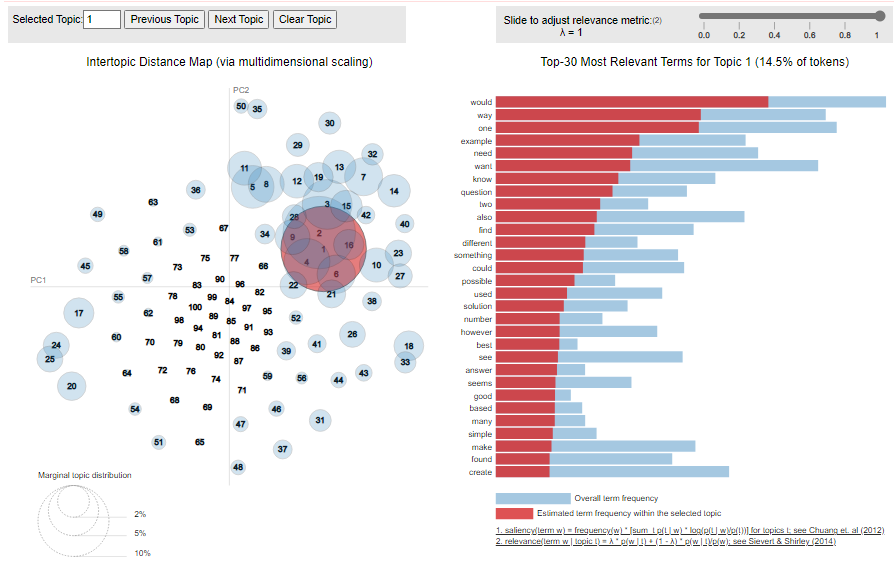
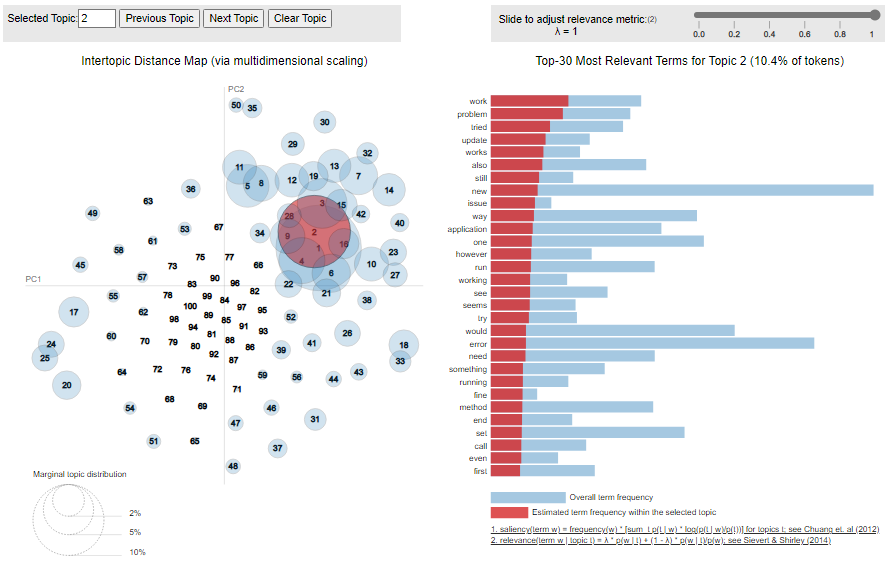
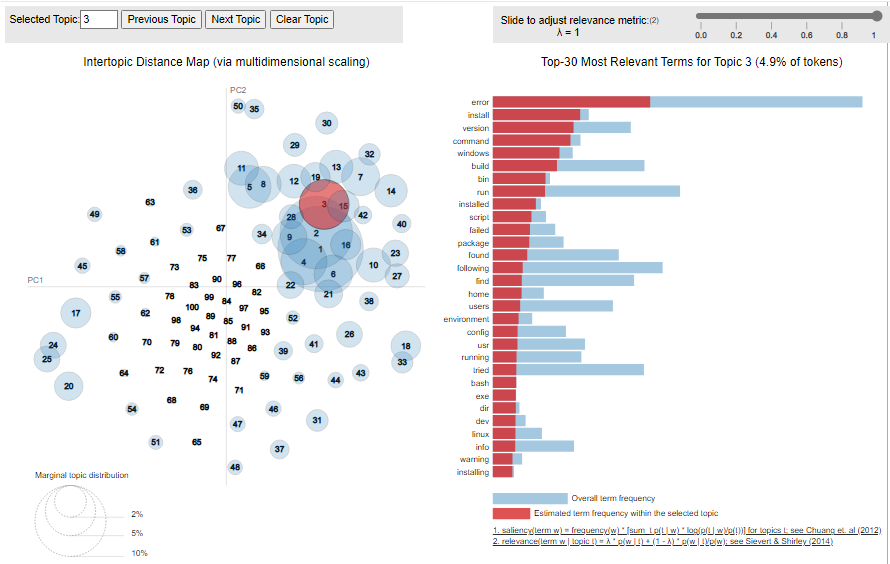

On notera qu'ici, le noms des topics est donné par le topics ayant le plus de termes. De manière décroissante, le topic 1 est celui avec le plus de termes et 100 avec le moins de termes. Dans nos dataframes, les topics n'ont pas été classés par ce typre d'attribution.  

Le topic 1 ded pyLDAvis semble être relatif au vocabulaire des questions, de manière général. Le second aux erreurs et problèmes, et le troisième aux installations de package.  
On ne va pas détailler plus ici ces topics.

In [79]:
df_doc_topic

,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9,topic_10,...,topic_92,topic_93,topic_94,topic_95,topic_96,topic_97,topic_98,topic_99,topic_100,dominant_topic
doc_0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.0,0.01,...,0.0,0.00,0.00,0.12,0.00,0.0,0.0,0.0,0.00,30
doc_1,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.24,0.0,0.01,...,0.0,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.00,55
doc_2,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.93,0.0,0.00,...,0.0,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.00,8
doc_3,0.00,0.0,0.0,0.09,0.0,0.0,0.00,0.00,0.0,0.00,...,0.0,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.00,55
doc_4,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.0,0.00,...,0.0,0.41,0.00,0.00,0.00,0.0,0.0,0.0,0.00,93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
doc_12707,0.00,0.0,0.0,0.00,0.0,0.0,0.03,0.00,0.0,0.00,...,0.0,0.00,0.04,0.00,0.00,0.0,0.0,0.0,0.02,86
doc_12708,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.0,0.00,...,0.0,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.00,79
doc_12709,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.0,0.00,...,0.0,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.00,15
doc_12710,0.02,0.0,0.0,0.00,0.0,0.0,0.00,0.16,0.0,0.00,...,0.0,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.00,79


In [85]:
dominant_topic

array([30, 55,  8, ..., 15, 79, 11], dtype=int64)

Evaluons la distribution des probabilités au sein du dataset grâce au dataframe "df_doc_topic". 

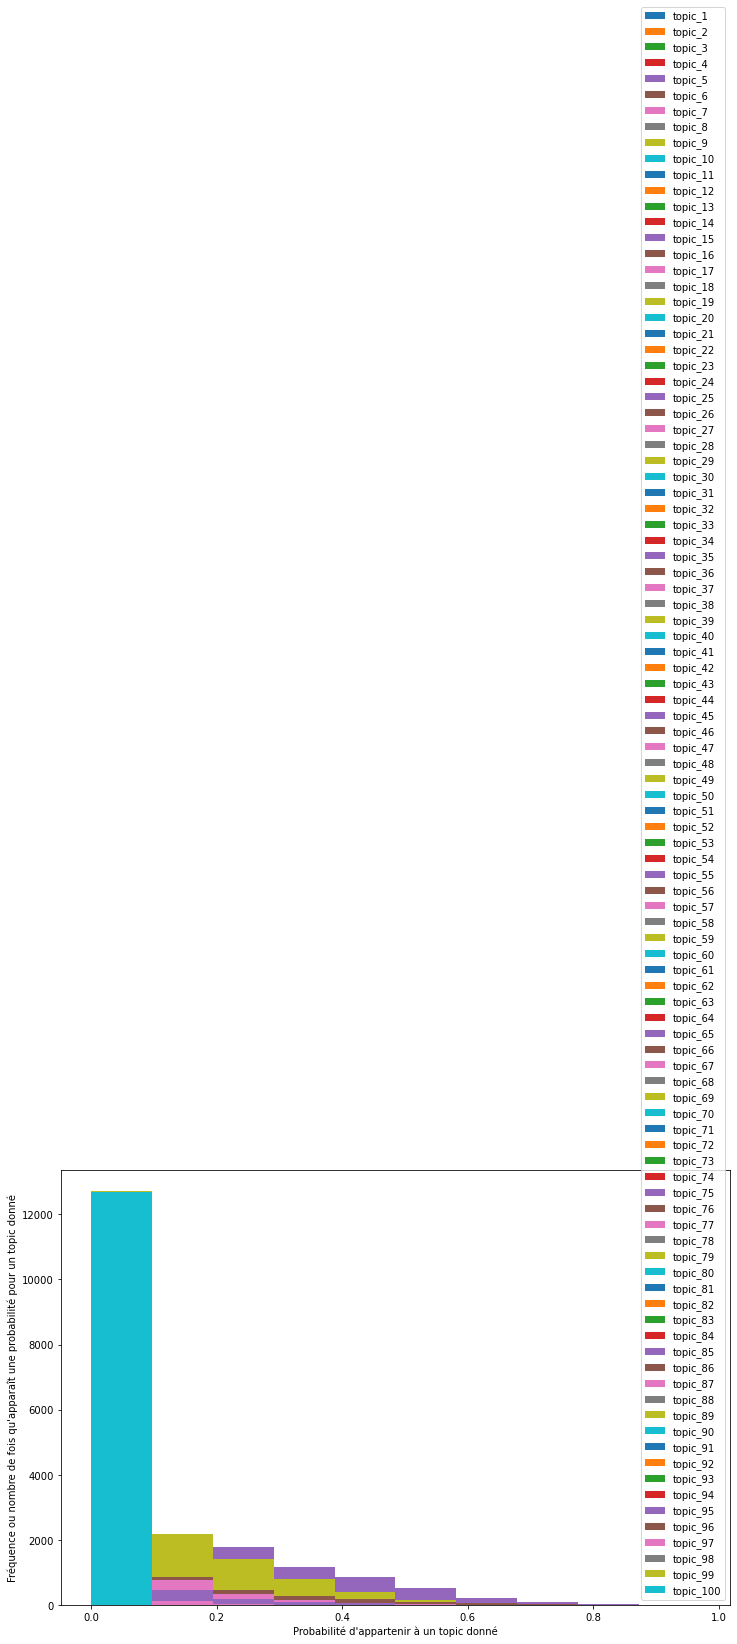

In [86]:
df_doc_topic.loc[:,'topic_1':'topic_100'].plot.hist(figsize=(12,8))
plt.ylabel("Fréquence ou nombre de fois qu'apparaît une probabilité pour un topic donné")
plt.xlabel("Probabilité d'appartenir à un topic donné")
plt.show()

Pour éviter de de regarder la distribution pour chacun des 100 topics sur un même graphe, on décide de mettre la matrice sous forme de ligne:

In [87]:
df_doc_topic_row = pd.melt(df_doc_topic.loc[:,'topic_1':'topic_100'])
df_doc_topic_row

,variable,value
0,topic_1,0.00
1,topic_1,0.00
2,topic_1,0.00
3,topic_1,0.00
4,topic_1,0.00
...,...,...
1271195,topic_100,0.02
1271196,topic_100,0.00
1271197,topic_100,0.00
1271198,topic_100,0.00


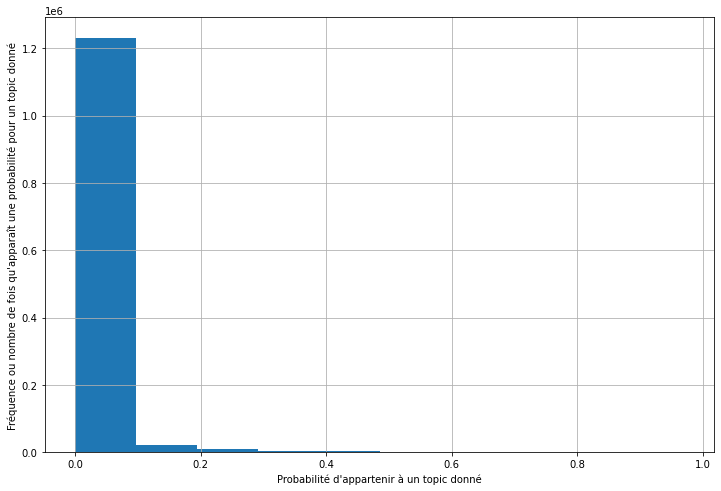

In [88]:
df_doc_topic_row['value'].plot.hist(figsize=(12,8))
plt.ylabel("Fréquence ou nombre de fois qu'apparaît une probabilité pour un topic donné")
plt.xlabel("Probabilité d'appartenir à un topic donné")
plt.grid()
plt.show()

In [89]:
df_doc_topic_row_nbzero = pd.DataFrame(df_doc_topic_row[df_doc_topic_row['value']==0].groupby(['variable']).size(),columns=['nb_zero'])
df_doc_topic_row_nbzero

,nb_zero
variable,
topic_1,11476
topic_10,11086
topic_100,12311
topic_11,10878
topic_12,10537
...,...
topic_95,10558
topic_96,11594
topic_97,11291


Text(0, 0.5, 'Numéro du Topic')

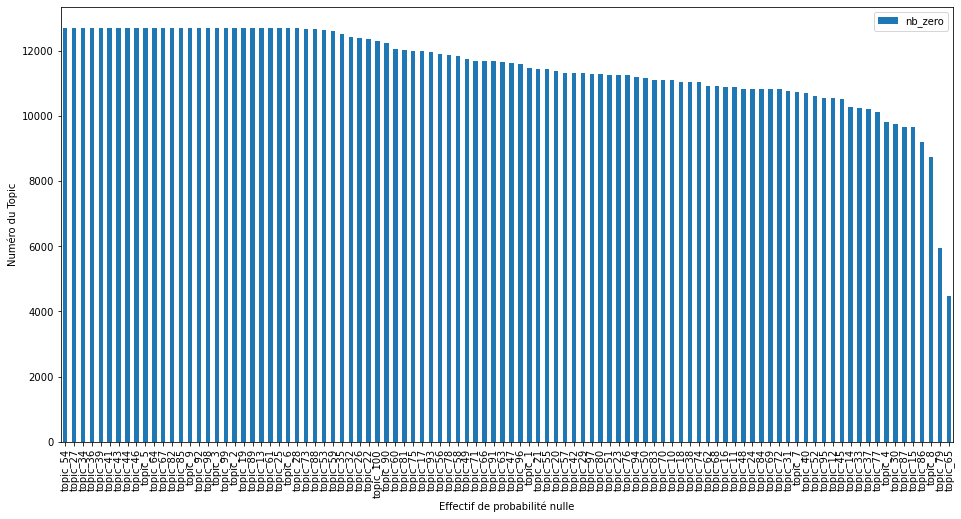

In [90]:
df_doc_topic_row_nbzero.sort_values(by='nb_zero', ascending=False).plot.bar(figsize=(16,8))
plt.xlabel('Effectif de probabilité nulle')
plt.ylabel('Numéro du Topic')

In [91]:
df_doc_topic_row_nonzero = df_doc_topic_row[df_doc_topic_row['value']>0]
df_doc_topic_row_nonzero

,variable,value
13,topic_1,0.03
23,topic_1,0.01
35,topic_1,0.01
48,topic_1,0.04
52,topic_1,0.05
...,...,...
1271139,topic_100,0.01
1271173,topic_100,0.02
1271175,topic_100,0.02
1271192,topic_100,0.01


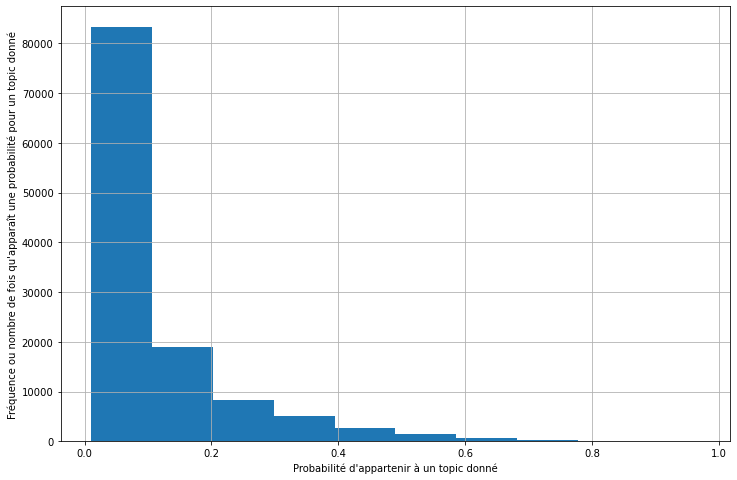

In [92]:
df_doc_topic_row_nonzero['value'].plot.hist(figsize=(12,8))
plt.ylabel("Fréquence ou nombre de fois qu'apparaît une probabilité pour un topic donné")
plt.xlabel("Probabilité d'appartenir à un topic donné")
plt.grid()
plt.show()

On va définir un seuil de probabilité minimum d'appartenance à un topic. L'étude précédente nous montre qu'il y a très peu de probabilité au dessus de 0.1. On décide d'utiliser ce seuil.

In [93]:
seuil_topic = 0.1
df_doc_topic['tag_seuil'] = [df_doc_topic.loc[value,'topic_1':'topic_100'][df_doc_topic.loc[value] >= seuil_topic ].index.to_list() for value in df_doc_topic.index]
df_doc_topic['tag_seuil'] 

doc_0                  [topic_30, topic_65, topic_95]
doc_1                   [topic_8, topic_55, topic_65]
doc_2                                       [topic_8]
doc_3                                      [topic_55]
doc_4        [topic_30, topic_33, topic_65, topic_93]
                               ...                   
doc_12707                                  [topic_86]
doc_12708              [topic_12, topic_51, topic_79]
doc_12709                                  [topic_15]
doc_12710                         [topic_8, topic_79]
doc_12711     [topic_8, topic_11, topic_65, topic_79]
Name: tag_seuil, Length: 12712, dtype: object

In [94]:
df_doc_topic['tag_seuil_len'] = [ len(value) for value in df_doc_topic['tag_seuil']]

In [95]:
df_doc_topic.index

Index(['doc_0', 'doc_1', 'doc_2', 'doc_3', 'doc_4', 'doc_5', 'doc_6', 'doc_7',
       'doc_8', 'doc_9',
       ...
       'doc_12702', 'doc_12703', 'doc_12704', 'doc_12705', 'doc_12706',
       'doc_12707', 'doc_12708', 'doc_12709', 'doc_12710', 'doc_12711'],
      dtype='object', length=12712)

In [96]:
df_doc_topic

,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9,topic_10,...,topic_94,topic_95,topic_96,topic_97,topic_98,topic_99,topic_100,dominant_topic,tag_seuil,tag_seuil_len
doc_0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.0,0.01,...,0.00,0.12,0.00,0.0,0.0,0.0,0.00,30,"[topic_30, topic_65, topic_95]",3
doc_1,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.24,0.0,0.01,...,0.00,0.00,0.00,0.0,0.0,0.0,0.00,55,"[topic_8, topic_55, topic_65]",3
doc_2,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.93,0.0,0.00,...,0.00,0.00,0.00,0.0,0.0,0.0,0.00,8,[topic_8],1
doc_3,0.00,0.0,0.0,0.09,0.0,0.0,0.00,0.00,0.0,0.00,...,0.00,0.00,0.00,0.0,0.0,0.0,0.00,55,[topic_55],1
doc_4,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.0,0.00,...,0.00,0.00,0.00,0.0,0.0,0.0,0.00,93,"[topic_30, topic_33, topic_65, topic_93]",4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
doc_12707,0.00,0.0,0.0,0.00,0.0,0.0,0.03,0.00,0.0,0.00,...,0.04,0.00,0.00,0.0,0.0,0.0,0.02,86,[topic_86],1
doc_12708,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.0,0.00,...,0.00,0.00,0.00,0.0,0.0,0.0,0.00,79,"[topic_12, topic_51, topic_79]",3
doc_12709,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.0,0.00,...,0.00,0.00,0.00,0.0,0.0,0.0,0.00,15,[topic_15],1
doc_12710,0.02,0.0,0.0,0.00,0.0,0.0,0.00,0.16,0.0,0.00,...,0.00,0.00,0.00,0.0,0.0,0.0,0.00,79,"[topic_8, topic_79]",2


In [97]:
df_doc_topic['tag_seuil_len']

doc_0        3
doc_1        3
doc_2        1
doc_3        1
doc_4        4
            ..
doc_12707    1
doc_12708    3
doc_12709    1
doc_12710    2
doc_12711    4
Name: tag_seuil_len, Length: 12712, dtype: int64

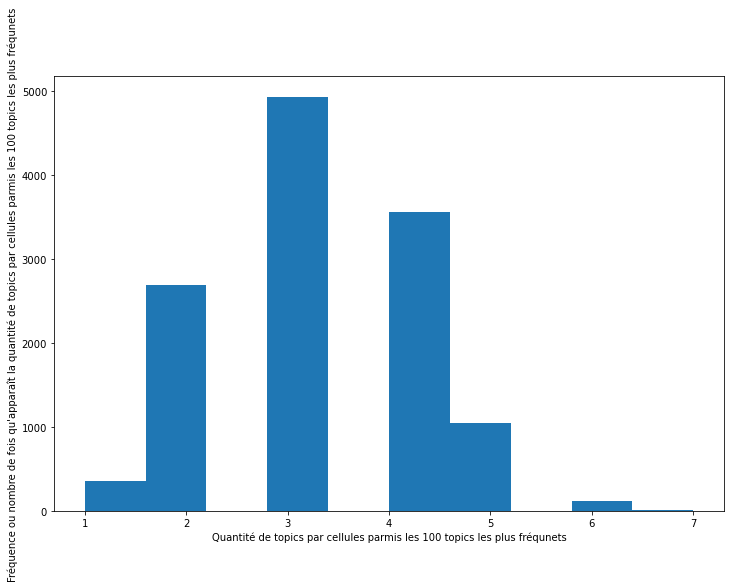

In [98]:
df_doc_topic['tag_seuil_len'].plot.hist(figsize=(12,8))
plt.ylabel("Fréquence ou nombre de fois qu'apparaît la quantité de topics par cellules parmis les 100 topics les plus fréqunets")
plt.xlabel("Quantité de topics par cellules parmis les 100 topics les plus fréqunets")
plt.show()

La plupart des documents possèdent 1 ou 0 topics attribués avec un seuil de 0.5. Une étude sur différent seuils mais qu'on ne détaillera pas ici, montre qu'en dessous de 0.4, on commence à trouver des documents ayant deux topics attribués. 

On va créer le dataframe contenant les poids les plus importants pour chaque mots de chaque topics:

In [100]:
# Topic-Keyword Matrix
df_topic_keywords = pd.DataFrame(lda.components_)

# Assign Column and Index
# vectorizer = estimator_lda_list[i_lda].best_estimator_[0]
vectorizer = vectorizer_
df_topic_keywords.columns = vectorizer.get_feature_names()
df_topic_keywords.index = topicnames

# View
df_topic_keywords.head()

C:\Users\daims\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


,00,000,0000,03,0px,0x,0x0,0xff,10,100,...,zeros,zip,zipped,zlib,zone,zoom,zoomed,zooming,zsh,zygoteinit
topic_1,0.010012,0.010013,0.010014,0.010009,0.010010,0.010011,0.010016,22.185680,0.012488,0.010014,...,0.010012,210.361685,18.479164,13.367389,0.010009,0.010192,0.010010,0.010009,0.010011,0.010010
topic_2,0.010009,0.010012,0.010011,0.010010,0.010010,0.010010,0.010011,0.010011,0.010010,0.010011,...,0.010011,0.010009,0.010011,0.010011,0.010013,0.010010,0.010009,0.010012,0.010010,0.010009
topic_3,0.010011,0.010010,0.010011,0.010010,0.010009,0.010011,0.010011,0.010011,0.010010,0.010009,...,0.010011,0.010009,0.010010,0.010010,0.010010,0.010009,0.010010,0.010010,0.010011,0.010009
topic_4,0.010053,0.010009,0.010010,0.010010,0.010009,0.010010,0.010009,0.010038,0.010047,0.010012,...,0.010011,0.010011,0.010008,0.010010,0.010021,0.010014,0.010012,0.010010,0.010012,0.010198
topic_5,0.010009,0.010010,0.010010,0.010010,0.010007,0.010010,0.010012,0.010009,0.010010,0.010012,...,0.010010,0.010010,0.010010,0.010011,0.010010,0.010010,0.010010,0.010008,0.010011,0.010009


In [101]:
len(lda.components_[0])

6839

Vérifions si les poids sont normalisés:

In [102]:
df_topic_keywords.describe()

,00,000,0000,03,0px,0x,0x0,0xff,10,100,...,zeros,zip,zipped,zlib,zone,zoom,zoomed,zooming,zsh,zygoteinit
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,0.693108,1.152714,0.521953,0.256022,0.366647,0.167777,0.567308,0.231782,1.743541,0.844295,...,0.776215,2.851622,0.194702,0.734855,0.787450,1.026568,0.206207,0.378572,0.539379,1.313139
std,6.830892,7.962487,5.119400,2.459676,3.561900,1.577641,5.566015,2.217565,14.653767,6.242281,...,7.641862,21.570886,1.846915,4.160768,7.619468,7.504607,1.230946,3.472729,5.293681,13.030705
min,0.010008,0.010008,0.010008,0.010008,0.010007,0.010008,0.010008,0.010009,0.010008,0.010008,...,0.010007,0.010008,0.010008,0.010008,0.010008,0.010008,0.010008,0.010008,0.010008,0.010008
25%,0.010009,0.010010,0.010010,0.010009,0.010010,0.010009,0.010010,0.010010,0.010010,0.010010,...,0.010010,0.010010,0.010009,0.010010,0.010010,0.010010,0.010010,0.010010,0.010009,0.010009
50%,0.010010,0.010011,0.010011,0.010010,0.010010,0.010010,0.010010,0.010011,0.010011,0.010011,...,0.010010,0.010011,0.010010,0.010011,0.010011,0.010010,0.010010,0.010010,0.010010,0.010010
75%,0.010012,0.010012,0.010011,0.010011,0.010011,0.010011,0.010011,0.010013,0.010013,0.010013,...,0.010011,0.010014,0.010011,0.010012,0.010012,0.010013,0.010011,0.010011,0.010011,0.010011
max,68.318942,75.290547,51.204016,24.606812,35.629437,15.786425,55.670836,22.185680,143.860454,59.479960,...,76.430392,210.361685,18.479164,30.758916,76.204689,69.161855,10.409386,34.691277,52.946825,130.317121


Dans l'étude présente, on a un certain nombre de mots qui dépend du dataset sur lequel on effectue la prédiction. Les poids générées ne sont pas normalisées ici, lorsqu'on regarde les valeurs max. On pourrait les normaliser, mais celà n'apportera pas d'apports supplémentaire dans l'étude.

In [103]:
# df_topic_keywords_scaled = df_topic_keywords.copy()
# for value in df_topic_keywords.index:
#     df_topic_keywords_scaled.loc[value] = df_topic_keywords.loc[value] /  df_topic_keywords.loc[value].sum(axis=0)
    
# df_topic_keywords_scaled

Choisissons de récupérer seulement les mots dominant de chaque topics: 

In [104]:
# Get dominant topic for each document
dominant_word_idx = np.argmax(df_topic_keywords.values, axis=1)
# dominant_word_idx

In [105]:
df_dominant_word = pd.DataFrame(index=df_topic_keywords.index)
df_dominant_word['dominant_word'] = df_topic_keywords.columns[dominant_word_idx]
df_dominant_word

,dominant_word
topic_1,byte
topic_2,tests
topic_3,tested
topic_4,public
topic_5,git
...,...
topic_96,loop
topic_97,height
topic_98,mysql
topic_99,web


In [106]:
df_dominant_word.loc['topic_65']

dominant_word    would
Name: topic_65, dtype: object

In [107]:
y_pred_ = Y_pred_lda[0]
y_pred_

array([1.40845070e-04, 1.40845070e-04, 1.40845070e-04, 1.40845070e-04,
       1.40845070e-04, 1.40845070e-04, 1.40845070e-04, 1.40845070e-04,
       1.40845070e-04, 1.46811732e-02, 1.40845070e-04, 1.40845070e-04,
       1.40845070e-04, 1.40845070e-04, 1.40845070e-04, 1.40845070e-04,
       1.40845070e-04, 2.65311901e-02, 1.40845070e-04, 1.40845070e-04,
       1.40845070e-04, 1.40845070e-04, 1.40845070e-04, 1.40845070e-04,
       1.40845070e-04, 1.40845070e-04, 1.40845070e-04, 1.40845070e-04,
       1.40845070e-04, 5.10899459e-01, 3.87991892e-02, 1.40845070e-04,
       1.40845070e-04, 1.40845070e-04, 1.40845070e-04, 1.40845070e-04,
       2.46210795e-02, 1.40845070e-04, 1.40845070e-04, 1.40845070e-04,
       1.40845070e-04, 1.40845070e-04, 1.40845070e-04, 1.40845070e-04,
       1.40845070e-04, 1.40845070e-04, 1.40845070e-04, 1.40845070e-04,
       1.40845070e-04, 1.40845070e-04, 4.94648979e-02, 1.40845070e-04,
       1.40845070e-04, 1.40845070e-04, 1.40845070e-04, 1.40845070e-04,
      

In [108]:
len(vectorizer.get_feature_names())

C:\Users\daims\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


6839

In [109]:
np.argmax(lda.components_[1])

6055

Mettons en place la fonction permettant de récupérer le keyword (nom donné ici au tag en non supervisé, pour dissocier avec celui en supervisé) à partir de la prédiction d'une pipeline.

In [110]:
def lda_pred_kw(vectorizer, lda,  y_pred_, seuil):
    # Renvoie la liste des mots dominants de chaque topics assignés à la prédiction Y_pred_ d'un document
    # dont la probabilité > seuil
    
    # vectorizer : cvect ou tfidf selon i_lda
    # lda: model_lda
    # y_pred_: prédiciton de la pipeline pour un document
    # seuil: seuil de probabilité d'assignation à un topic
    
    # Y_pred: list(list) : [[],[],[]] :  non utilisé ici    
    
    idx = 0
    list_tropic_global = []
    idx_keyword = []
    idx_topic = np.array(np.where(y_pred_ >= seuil))
    for idx_topic_iter in idx_topic[0]:
        #print("idx_topic_iter = " + str(idx_topic_iter))
        if len(lda.components_[idx_topic_iter])>0:
            idx_keyword.append(np.argmax(lda.components_[idx_topic_iter]))
            list_topic = [vectorizer.get_feature_names()[idx_keyword_iter] for idx_keyword_iter in idx_keyword]
            list_tropic_global.append(list_topic)
        #print(df_dominant_word.iloc[idx_topic_iter])
    return list_topic


In [111]:
vectorizer_ = pipe_lda[0]

In [112]:
vectorizer_.get_feature_names()[0]

'00'

In [113]:
lda_pred_kw(vectorizer, lda,Y_pred_lda[1], 0.1)

['memory', 'spring', 'would']

In [114]:
df_dominant_word

,dominant_word
topic_1,byte
topic_2,tests
topic_3,tested
topic_4,public
topic_5,git
...,...
topic_96,loop
topic_97,height
topic_98,mysql
topic_99,web


In [115]:
df_dominant_word.values.flatten()

array(['byte', 'tests', 'tested', 'public', 'git', 'dropped', 'include',
       'memory', 'stroke', 'std', 'model', 'color', 'subsystem', 'table',
       'text', 'java', 'lookup', 'system', 'bounds', 'new', 'content',
       'article', 'self', 'python', 'theta', 'design', 'execute', 'gzip',
       'true', 'json', 'new', 'mongodb', 'array', 'recommend', 'zero',
       'target', 'data', 'time', 'write', 'file', 'email', 'chrome',
       'strangely', 'cgi', 'request', 'stroke', 'node', 'int', 'location',
       'date', 'key', 'project', 'analysis', 'security', 'spring', 'mode',
       'video', 'move', 'factor', 'space', 'xamarin', 'view', 'django',
       'android', 'would', 'thread', 'view', 'app', 'read', 'react',
       'lib', 'ios', 'ipython', 'module', 'directory', 'org', 'function',
       'order', 'work', 'angular', 'mysql', 'asyncio', 'form', 'image',
       'flex', 'error', 'user', 'migrate', 'simd', 'www', 'path', 'mysql',
       'random', 'git', 'server', 'loop', 'height', 'mys

In [116]:
df_doc_topic

,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9,topic_10,...,topic_94,topic_95,topic_96,topic_97,topic_98,topic_99,topic_100,dominant_topic,tag_seuil,tag_seuil_len
doc_0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.0,0.01,...,0.00,0.12,0.00,0.0,0.0,0.0,0.00,30,"[topic_30, topic_65, topic_95]",3
doc_1,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.24,0.0,0.01,...,0.00,0.00,0.00,0.0,0.0,0.0,0.00,55,"[topic_8, topic_55, topic_65]",3
doc_2,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.93,0.0,0.00,...,0.00,0.00,0.00,0.0,0.0,0.0,0.00,8,[topic_8],1
doc_3,0.00,0.0,0.0,0.09,0.0,0.0,0.00,0.00,0.0,0.00,...,0.00,0.00,0.00,0.0,0.0,0.0,0.00,55,[topic_55],1
doc_4,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.0,0.00,...,0.00,0.00,0.00,0.0,0.0,0.0,0.00,93,"[topic_30, topic_33, topic_65, topic_93]",4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
doc_12707,0.00,0.0,0.0,0.00,0.0,0.0,0.03,0.00,0.0,0.00,...,0.04,0.00,0.00,0.0,0.0,0.0,0.02,86,[topic_86],1
doc_12708,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.0,0.00,...,0.00,0.00,0.00,0.0,0.0,0.0,0.00,79,"[topic_12, topic_51, topic_79]",3
doc_12709,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.0,0.00,...,0.00,0.00,0.00,0.0,0.0,0.0,0.00,15,[topic_15],1
doc_12710,0.02,0.0,0.0,0.00,0.0,0.0,0.00,0.16,0.0,0.00,...,0.00,0.00,0.00,0.0,0.0,0.0,0.00,79,"[topic_8, topic_79]",2


In [117]:
seuil_topic = 0.1
df_doc_topic['lda_pred_kw'] = [ lda_pred_kw(vectorizer, lda,df_doc_topic.loc[value,'topic_1':'topic_100'], seuil_topic) for value in df_doc_topic.index]
df_doc_topic['lda_pred_kw'] 

C:\Users\daims\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


doc_0               [json, would, server]
doc_1             [memory, spring, would]
doc_2                            [memory]
doc_3                            [spring]
doc_4        [json, array, would, random]
                         ...             
doc_12707                         [error]
doc_12708              [color, key, work]
doc_12709                          [text]
doc_12710                  [memory, work]
doc_12711    [memory, model, would, work]
Name: lda_pred_kw, Length: 12712, dtype: object

In [118]:
df_doc_topic

,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9,topic_10,...,topic_95,topic_96,topic_97,topic_98,topic_99,topic_100,dominant_topic,tag_seuil,tag_seuil_len,lda_pred_kw
doc_0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.0,0.01,...,0.12,0.00,0.0,0.0,0.0,0.00,30,"[topic_30, topic_65, topic_95]",3,"[json, would, server]"
doc_1,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.24,0.0,0.01,...,0.00,0.00,0.0,0.0,0.0,0.00,55,"[topic_8, topic_55, topic_65]",3,"[memory, spring, would]"
doc_2,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.93,0.0,0.00,...,0.00,0.00,0.0,0.0,0.0,0.00,8,[topic_8],1,[memory]
doc_3,0.00,0.0,0.0,0.09,0.0,0.0,0.00,0.00,0.0,0.00,...,0.00,0.00,0.0,0.0,0.0,0.00,55,[topic_55],1,[spring]
doc_4,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.0,0.00,...,0.00,0.00,0.0,0.0,0.0,0.00,93,"[topic_30, topic_33, topic_65, topic_93]",4,"[json, array, would, random]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
doc_12707,0.00,0.0,0.0,0.00,0.0,0.0,0.03,0.00,0.0,0.00,...,0.00,0.00,0.0,0.0,0.0,0.02,86,[topic_86],1,[error]
doc_12708,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.0,0.00,...,0.00,0.00,0.0,0.0,0.0,0.00,79,"[topic_12, topic_51, topic_79]",3,"[color, key, work]"
doc_12709,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.0,0.00,...,0.00,0.00,0.0,0.0,0.0,0.00,15,[topic_15],1,[text]
doc_12710,0.02,0.0,0.0,0.00,0.0,0.0,0.00,0.16,0.0,0.00,...,0.00,0.00,0.0,0.0,0.0,0.00,79,"[topic_8, topic_79]",2,"[memory, work]"


In [119]:
# On crée un document unique comprenant une liste de tout les mots du corpus.
list_kw_total = []
for i in range(df_doc_topic.shape[0]):
    list_kw_total.extend(df_doc_topic['lda_pred_kw'].iloc[i])

In [120]:
import nltk
freq_kw = nltk.FreqDist(list_kw_total)
freq_kw

FreqDist({'would': 6825, 'work': 5043, 'memory': 2112, 'error': 2029, 'new': 1461, 'text': 1405, 'user': 1400, 'array': 1388, 'public': 1384, 'json': 913, ...})

In [121]:
len(freq_kw)

77

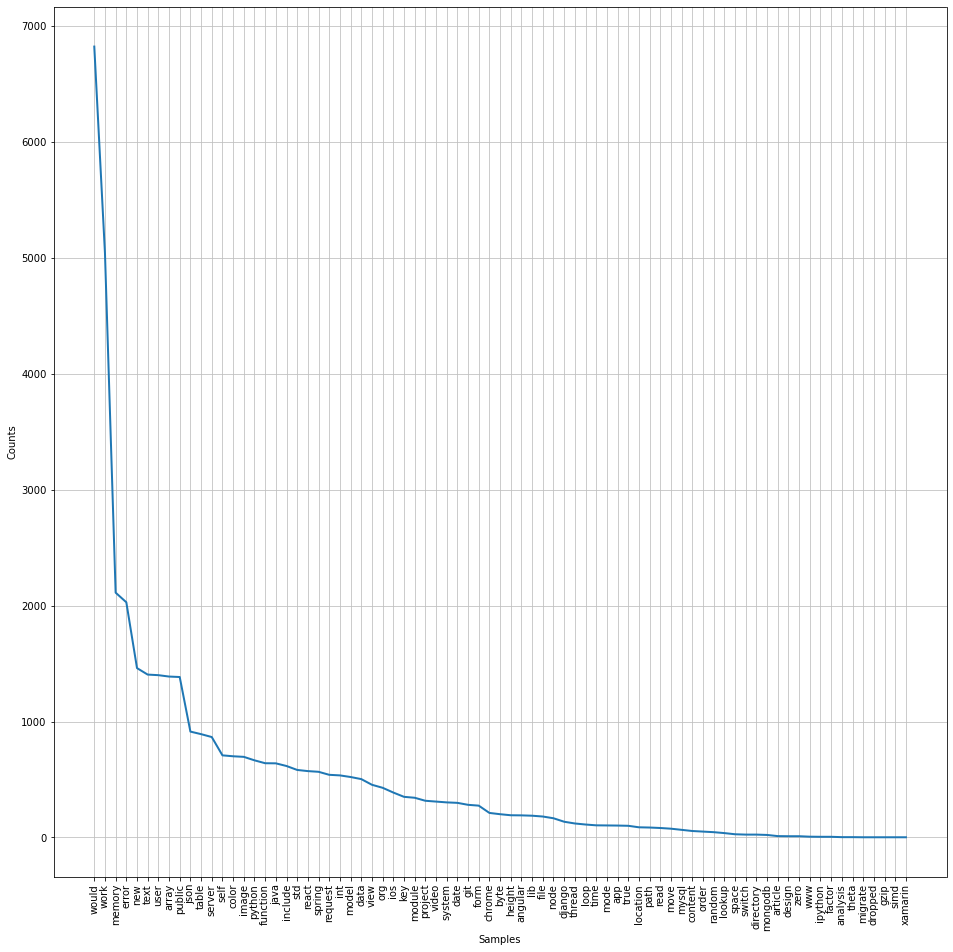

In [122]:
# Tracé des 100 mots les plus fréquents
plt.figure(figsize=(16,16))
freq_kw.plot(100)
plt.show()

In [123]:
df_doc_topic['lda_pred_kw'].values.flatten()

array([list(['json', 'would', 'server']),
       list(['memory', 'spring', 'would']), list(['memory']), ...,
       list(['text']), list(['memory', 'work']),
       list(['memory', 'model', 'would', 'work'])], dtype=object)

# Comparaison Supervisé vs LDA
Une étude complémentaire visait ici à comparer les approches en supervisées et en non supervisées, et notamment de voir s'il y avait une corrélation entre les tags de l'approche supervisée et les keywords ou topics de l'approche non supervisées, mais elle de sera pas réalisée ici car gourmande en temps.  
Une des idées pour réaliser ce travail était de comparer les distributions entre tags et topics, ou entre tags et keywords, par des approches comme la KL Divergence.